#  Barco Pirata — Aprendizaje por Refuerzo

#### Autores: Brian Bedoya Piedrahita, Daniel Moraleda Sánchez y David Santiago Ruiz

---

### Descripción del problema

Un agente controla un barco pirata en un mapa de **8×10 celdas** con mar abierto, islas, dos tipos de tormenta, corrientes marinas, un maelstrom y un puerto base. El objetivo es recoger los cuatro cofres del mapa — cada uno con distinto valor — y regresar al puerto antes de agotar las provisiones, adaptando la ruta a la dirección cambiante del viento.

Lo que hace este problema **genuinamente original y no trivial** para RL son cinco elementos simultáneos:

- **Viento variable en el estado** — el agente conoce la dirección actual del viento y aprende a adaptar su ruta: aprovechar viento de cola, evitar rutas en contra. La misma acción tiene distinta distribución de transición según el viento, por lo que la dirección del viento forma parte del estado para preservar la propiedad de Markov
- **4 cofres con valores distintos** — no todos los tesoros valen igual (+20, +35, +50, +70); la política óptima implica ponderar riesgo y recompensa explícitamente: ¿merece la pena arriesgarse al legendario rodeado de tormenta severa con pocas provisiones?
- **Provisiones discretizadas en 4 niveles** — la política cambia cualitativamente entre niveles: con provisiones ALTAS el agente puede explorar, con provisiones CRÍTICAS debe ir directamente al puerto
- **Corrientes marinas y maelstrom** — elementos deterministas del mapa que el agente aprende a explotar como atajos o evitar como trampas
- **Dos tipos de tormenta** — riesgo gradual: tormenta moderada y tormenta severa con distintos niveles de desvío, forzando al agente a diferenciar zonas de riesgo

---

## 2.1 Motivación del problema

El Aprendizaje por Refuerzo destaca en problemas donde un agente debe tomar decisiones secuenciales bajo incertidumbre, aprendiendo de la interacción con el entorno sin conocimiento previo de su dinámica. El entorno del Barco Pirata captura precisamente esta naturaleza, combinando cinco fuentes de complejidad simultáneas en un único problema cohesionado.

### ¿Por qué es interesante desde la perspectiva de la IA?

**1. Navegación bajo incertidumbre adaptativa**

El viento no solo es estocástico — su dirección cambia durante el episodio y forma parte del estado. El agente no aprende un camino fijo sino una política π(s) que decide de forma distinta según sople el viento: con viento de cola hacia el cofre épico, la ruta directa puede compensar el riesgo de la tormenta severa; con viento en contra, esa misma ruta es suicida. Esto obliga al agente a razonar sobre incertidumbre de forma genuinamente adaptativa.

**2. Optimización combinatoria bajo riesgo y valor heterogéneo**

Con cuatro cofres de valores distintos (+20, +35, +50, +70) existen 4! = 24 órdenes posibles de recogida. A diferencia de problemas donde todos los objetivos tienen el mismo valor, aquí el agente debe ponderar riesgo y recompensa explícitamente: el cofre legendario (+70) está rodeado de tormenta severa — ¿merece la pena intentarlo con pocas provisiones? La política óptima de ordenación no puede calcularse de forma estática porque depende de la dirección actual del viento y el nivel de provisiones.

**3. Gestión de recursos bajo horizonte finito**

Las provisiones, discretizadas en cuatro niveles cualitativos, introducen una restricción que cambia la política óptima de forma no lineal. El mismo par (posición, cofres_recogidos) requiere decisiones completamente distintas en nivel ALTO que en nivel CRÍTICO — en el primero el agente puede explorar rutas largas, en el segundo debe ir directamente al puerto ignorando cofres cercanos.

**4. Explotación de elementos deterministas del mapa**

Las corrientes marinas desplazan el barco automáticamente en una dirección fija. A diferencia de las tormentas, que siempre son un riesgo, las corrientes son ambivalentes: una corriente que lleva hacia el cofre épico es un atajo gratuito si el agente va en esa dirección, pero puede alejarlo del puerto si lo arrastra en dirección contraria. El agente aprende a explotar o evitar estos elementos según el contexto — un tipo de razonamiento que no aparece en problemas de navegación estándar.

**5. Gestión de amenazas asimétricas**

El maelstrom atrapa al barco durante dos turnos consumiendo provisiones sin posibilidad de escapar. A diferencia de las tormentas (riesgo probabilístico), el maelstrom es una penalización determinista severa. Esto crea zonas de evitación absolutas en el mapa de política aprendida — visualmente muy claras y fáciles de analizar en la memoria.

### Aplicaciones en el mundo real

Aunque el entorno es una simulación, el problema formalizado es análogo a escenarios de alta relevancia:

- **Robótica de exploración** — rovers planetarios (Mars Perseverance) que recogen muestras de distintas prioridades científica con batería limitada, adaptando la ruta a las condiciones variables del terreno
- **Logística marítima** — buques que optimizan el orden de escalas de carga con restricciones de combustible, aprovechando corrientes marinas favorables y evitando zonas de mal tiempo
- **Drones de reparto con prioridad variable** — vehículos autónomos que gestionan múltiples entregas de distinta urgencia con batería limitada en entornos con viento variable

### ¿Por qué RL y no algoritmos clásicos?

El algoritmo A\* [Hart et al., 1968] garantiza el camino de coste mínimo en entornos **deterministas**, pero falla por dos razones en este entorno. Primero, el viento estocástico invalida la planificación: el camino calculado como óptimo puede no ejecutarse tal como se proyectó. Segundo, la dirección del viento cambia durante el episodio, haciendo que el grafo de costes que A\* necesita sea no estacionario. El RL, al aprender directamente de la interacción, construye una política robusta que maximiza la recompensa esperada $\mathbb{E}[G_t]$ bajo cualquier realización del viento, sin asumir conocimiento previo de la dinámica de transición.

---

## 2.2 Modelado del problema — Formalización MDP

Un Proceso de Decisión de Markov (MDP) se define como la tupla $\mathcal{M} = (\mathcal{S}, \mathcal{A}, T, R, \gamma)$. A continuación se detalla y justifica cada componente para el entorno del Barco Pirata.

### Espacio de Estados $\mathcal{S}$

El estado en cada instante $t$ se define como:

$$s_t = (\text{fila}, \text{columna}, c_0, c_1, c_2, c_3, \text{nivel\_prov}, \text{dir\_viento})$$

| Variable | Tipo | Rango | Justificación |
|---|---|---|---|
| `fila` | Discreto | $[0, 7]$ | Posición vertical en el grid 8×10 |
| `columna` | Discreto | $[0, 9]$ | Posición horizontal en el grid 8×10 |
| $c_0, c_1, c_2, c_3$ | Binario | $\{0,1\}^4 = 16$ | Estado de cada cofre — 16 combinaciones |
| `nivel_prov` | Discreto | $\{0,1,2,3\}$ | Nivel cualitativo de provisiones |
| `dir_viento` | Discreto | $\{N,S,O,E\}$ | Dirección actual del viento |

**Discretización de provisiones en 4 niveles:**

$$\text{nivel\_prov}(p) = \begin{cases} 3 \text{ (ALTO)}    & p \geq 38 \\ 2 \text{ (MEDIO)}   & 26 \leq p < 38 \\ 1 \text{ (BAJO)}    & 13 \leq p < 26 \\ 0 \text{ (CRÍTICO)} & p < 13 \end{cases}$$

**Tamaño total del espacio de estados:**

$$|\mathcal{S}| = 8 \times 10 \times 2^4 \times 4 \times 4 = 20.480 \text{ estados}$$

Con 500.000 episodios de ~60 pasos cada uno se generan ~30.000.000 de transiciones, permitiendo visitar cada par estado-acción en media unas 6 veces.

> **Propiedad de Markov:** tanto `nivel_prov` como `dir_viento` son imprescindibles. Sin `nivel_prov`, el agente no puede distinguir situaciones que requieren políticas opuestas — ir a por el legendario con provisiones ALTAS vs ir directamente al puerto con provisiones CRÍTICAS. Sin `dir_viento`, la misma acción produce distribuciones de transición distintas según sople el viento, violando la propiedad Markoviana. Las corrientes y el maelstrom no forman parte del estado porque son celdas fijas del mapa — el agente aprende sus posiciones y efectos igual que aprende dónde están las islas.

### Espacio de Acciones $\mathcal{A}$

$$\mathcal{A} = \{\text{NORTE}, \text{SUR}, \text{OESTE}, \text{ESTE}\}$$

Cuatro acciones discretas de movimiento. No existe acción de recoger — el cofre se recoge automáticamente al pisar su celda. No existe acción de esperar — el *living penalty* hace que esperar sea siempre subóptimo. El maelstrom consume turnos automáticamente — tampoco hay acción de escape.

### Función de Recompensa $R(s, a, s')$

Los cuatro cofres tienen valores distintos que reflejan su dificultad de acceso:

$$R(s, a, s') = \begin{cases} +v_i & \text{si se recoge el cofre } i \text{ en } s', \quad v \in \{20, 35, 50, 70\} \\ +100 & \text{si se llega al puerto con todos los cofres} \\ -150 & \text{si las provisiones llegan a 0} \\ -5 & \text{por turno atrapado en el maelstrom} \\ -1 & \text{en cualquier otro caso (living penalty)} \end{cases}$$

**Justificación de cada término:**
- $-1$ por paso: evita rodeos y obliga al agente a ser eficiente con las provisiones
- $v_i \in \{20, 35, 50, 70\}$: el valor de cada cofre refleja su riesgo de acceso — el legendario (+70) está rodeado de tormenta severa y solo es accesible con buenas provisiones y viento favorable
- $+100$ victoria: bonus de finalización que garantiza que completar el episodio sea siempre preferible a estrategias parciales
- $-150$ agotamiento: penalización severa — morir de hambre debe ser siempre la peor terminación posible
- $-5$ maelstrom: penalización por turno que disuade de entrar en el maelstrom incluso con provisiones altas

**Verificación anti-reward hacking:**

| Estrategia | Recompensa total |
|---|---|
| Victoria óptima (~35 pasos) | $100 + 20 + 35 + 50 + 70 - 35 = +240$ ✅ |
| Recoger solo legendario y morir | $70 - 10 - 150 = -90$ ❌ |
| Morir directamente | $-150$ ❌ peor caso |
| Quedarse atrapado en maelstrom hasta morir | $-5 \times 2 - 150 < -150$ ❌ |

### Dinámica de Transición $T(s, a, s')$

La transición es **estocástica y dependiente de la dirección del viento**. Las probabilidades de desvío dependen de la relación entre la acción elegida y la dirección actual del viento:

$$T(s' \mid s, a, \text{dir\_viento}) = \begin{cases} p_{\text{rel}} & \text{si } s' \text{ corresponde a la dirección elegida} \\ \frac{1-p_{\text{rel}}}{2} & \text{si } s' \text{ corresponde a cada perpendicular} \end{cases}$$

donde $p_{\text{rel}}$ depende de la relación movimiento-viento:

| Relación acción-viento | $p_{\text{dir}}$ | $p_{\perp}$ cada una |
|---|---|---|
| A favor (mismo sentido) | 0.80 | 0.10 |
| Perpendicular | 0.65 | 0.175 |
| En contra (sentido opuesto) | 0.50 | 0.25 |

En celdas de tormenta, $p_{\text{dir}}$ se reduce adicionalmente:

| Tipo de celda | Reducción de $p_{\text{dir}}$ |
|---|---|
| Tormenta moderada | $-0.15$ |
| Tormenta severa | $-0.25$ |

**Corrientes marinas** — tras el movimiento, si el agente ocupa una celda de corriente, se desplaza automáticamente una celda adicional en la dirección fija de la corriente (determinista).

**Maelstrom** — al entrar en la celda de maelstrom, el agente queda inmovilizado durante 2 turnos, perdiendo $-5$ de recompensa y 1 provisión por turno.

**Rebote** — si el viento o una corriente llevan al barco contra una isla o fuera del mapa, el barco permanece en su celda actual.

**Actualización del viento** — al final de cada paso, el viento cambia de dirección con probabilidad $p_{\text{cambio}} = 0.15$; si cambia, gira 90° (perpendicular aleatorio):

$$\text{dir\_viento}_{t+1} = \begin{cases} \text{dir\_viento}_t & \text{con prob. } 0.85 \\ \text{perpendicular aleatoria} & \text{con prob. } 0.15 \end{cases}$$

**Justificación de los valores de probabilidad:**

| Rango de $p_{\text{dir}}$ (a favor) | Comportamiento |
|---|---|
| $p \geq 0.90$ | Q-Learning y SARSA convergen a la misma política — sin contraste |
| $p \in [0.75, 0.85]$ | Contraste claro y convergencia estable ✅ |
| $p \leq 0.60$ | Entorno demasiado caótico — convergencia muy lenta |

### Factor de Descuento $\gamma$

$$\gamma = 0.97$$

Con episodios de ~50–90 pasos, una recompensa a 60 pasos vale $0.97^{60} \approx 0.16$ — todavía significativa para que el agente planifique la ruta de regreso al puerto. Valores menores ($\gamma = 0.90$) producen un agente miope que ignora el cofre legendario por estar lejos; valores mayores ($\gamma = 0.99$) ralentizan la propagación del gradiente de valor.

### Tipo de episodio

El problema es **episódico**. Cada episodio termina cuando:

| Condición | `terminated` | `truncated` | Recompensa final |
|---|---|---|---|
| Puerto alcanzado con los 4 cofres | ✅ | — | $+100$ bonus |
| Provisiones = 0 | ✅ | — | $-150$ |
| Pasos > 300 (safety limit) | — | ✅ | $0$ |

### Decisiones de diseño del entorno

**¿Por qué 4 cofres con valores distintos?**

Con $N$ cofres el espacio de recogida tiene $2^N$ combinaciones:

| Cofres | Combinaciones | Órdenes posibles | Estados totales |
|---|---|---|---|
| 2 | 4 | 2 | ~2.560 |
| 3 | 8 | 6 | ~5.120 |
| **4** | **16** | **24** | **20.480** ✅ |
| 5 | 32 | 120 | ~40.960 |

4 cofres genera 24 órdenes posibles de recogida y, al tener valores distintos (+20, +35, +50, +70), obliga al agente a ponderar riesgo y recompensa explícitamente. Con cofres de igual valor la ordenación solo dependería de la distancia — un problema más simple. Con 5 cofres el espacio de estados se duplica sin añadir complejidad cualitativa proporcional.

**¿Por qué posiciones fijas y no aleatorias?**

Si los cofres aparecieran en posiciones aleatorias cada episodio, sus coordenadas deberían formar parte del estado. Eso multiplicaría el espacio de estados por el número de posiciones posibles del grid — inviable para Q-Learning tabular. Con posiciones fijas el agente aprende el mapa en los primeros episodios de exploración, análogamente a entornos clásicos como FrozenLake o Taxi.

**¿Por qué grid 8×10 y no otro tamaño?**

| Grid | Celdas | Estados totales | Tiempo entrenamiento |
|---|---|---|---|
| 6×8 | 48 | ~7.680 | ~20 min — demasiado rápido |
| **8×10** | **80** | **20.480** | **~1-2h por algoritmo** ✅ |
| 10×12 | 120 | ~30.720 | ~3-4h — límite superior |

La asimetría 8×10 genera mayor variedad de rutas alternativas que un grid cuadrado del mismo tamaño.

**¿Por qué MAX_PROV = 50 y 4 niveles cualitativos?**

Distancia mínima teórica para completar el episodio (distancia Manhattan, sin viento, orden óptimo):

```
Inicio(0,0) → Cofre raro(1,5):       |0-1|+|0-5| =  6 pasos
Cofre raro(1,5) → Cofre épico(4,9):  |1-4|+|5-9| =  7 pasos
Cofre épico(4,9) → Cofre común(6,9): |4-6|+|9-9| =  2 pasos
Cofre común(6,9) → Cofre leg.(7,8):  |6-7|+|9-8| =  2 pasos
Cofre leg.(7,8) → Puerto(7,0):       |7-7|+|8-0| =  8 pasos
──────────────────────────────────────────────────────────────
Distancia mínima teórica:                              25 pasos
```

50 provisiones = **2× la distancia mínima**, dejando margen para el desvío por viento pero sin permitir rodeos arbitrarios.

Los 4 niveles cualitativos en lugar del valor exacto (0–50) reducen el estado de $8 \times 10 \times 16 \times 51 \times 4 = 261.120$ a $20.480$ estados — **13× más manejable** — sin pérdida de calidad de política, ya que el comportamiento óptimo cambia en umbrales cualitativos, no linealmente.

**¿Por qué `dir_viento` entra en el estado?**

Sin `dir_viento` en el estado, la misma tupla (posición, cofres, provisiones) puede corresponder a dos situaciones con distribuciones de transición completamente distintas: viento de cola hacia el cofre épico (probabilidad 0.80 de llegar) vs viento en contra (probabilidad 0.50). El agente no podría aprender políticas distintas para ambas situaciones y aprendería una política promediada — subóptima en ambos casos.

---

## 2.3 Estado del arte

### Clasificación del problema en la literatura

El entorno del Barco Pirata puede clasificarse como un **Stochastic Shortest Path Problem (SSP)** con objetivos múltiples y restricción de recursos. Esta clase de MDP, en la que las transiciones son estocásticas y el objetivo es alcanzar un estado terminal minimizando el coste esperado, ha sido ampliamente estudiada tanto en investigación de operaciones como en aprendizaje automático. La presencia de viento variable en el estado y de elementos deterministas del mapa (corrientes, maelstrom) introduce adicionalmente características propias de los **entornos semi-deterministas**, donde coexisten fuentes de aleatoriedad controlables e incontrolables.

### Enfoques clásicos y sus limitaciones

Históricamente, los problemas de navegación en entornos discretos se han abordado mediante algoritmos de búsqueda en grafos. El algoritmo A\* [Hart et al., 1968], que garantiza optimalidad en entornos deterministas mediante una función heurística admisible, es el referente clásico. Sin embargo, A\* presenta dos limitaciones fundamentales en nuestro entorno. En primer lugar, requiere conocimiento completo y estático del grafo de costes — la presencia de viento estocástico hace que el coste de cada arco sea una variable aleatoria, no un valor fijo. En segundo lugar, la dirección del viento cambia dinámicamente durante el episodio, haciendo que el grafo de costes sea no estacionario: el camino calculado como óptimo en el instante $t$ puede no serlo en $t+1$.

Extensiones deterministas como el algoritmo de Dijkstra [Dijkstra, 1959] comparten las mismas limitaciones. Los enfoques de planificación robusta bajo incertidumbre, como los basados en árboles de decisión o programación dinámica con modelo conocido [Bellman, 1957], requieren conocimiento explícito de la función de transición $T(s, a, s')$ — información que en escenarios reales de navegación marítima raramente está disponible con precisión.

### Aprendizaje por Refuerzo como alternativa model-free

El RL supera estas limitaciones al aprender la política óptima directamente de la interacción con el entorno, sin necesidad de conocer $T$ ni $R$ de forma explícita. En la literatura de RL, el problema análogo más cercano al nuestro es el **Windy Gridworld** de Sutton y Barto [2018, cap. 6.5]: un agente navega un grid donde cada columna tiene un viento fijo que desplaza el agente verticalmente. Este entorno de referencia sirve para ilustrar precisamente las diferencias entre Q-Learning y SARSA en presencia de estocasticidad, que es uno de los objetivos centrales de este trabajo. Nuestro entorno extiende el Windy Gridworld en tres dimensiones: el viento es global y variable (no fijo por columna), el estado incluye la dirección del viento como variable observable, y el agente gestiona múltiples objetivos con valores heterogéneos.

El ejemplo del **Cliff Walking** [Sutton y Barto, 2018, cap. 6.7] ilustra el contraste teórico más importante entre Q-Learning y SARSA: Q-Learning aprende la política óptima pero acumula más penalizaciones durante el entrenamiento al tomar rutas arriesgadas; SARSA aprende una política subóptima pero más segura que funciona mejor durante el entrenamiento con exploración activa. Las tormentas severas y el maelstrom de nuestro entorno reproducen exactamente el papel del acantilado en este ejemplo, con la diferencia de que nuestro entorno añade elementos de valor heterogéneo y viento variable que enriquecen el análisis.

### RL tabular vs Deep RL

Los métodos tabulares como Q-Learning [Watkins y Dayan, 1992] y SARSA [Rummery y Niranjan, 1994] son eficientes cuando el espacio de estados es discreto y manejable. Con $|\mathcal{S}| = 20.480$ estados, nuestro entorno es perfectamente abordable con estas técnicas. Monte Carlo off-policy [Sutton y Barto, 2018, cap. 5] ofrece un tercer punto de comparación relevante: a diferencia de Q-Learning y SARSA, aprende del retorno completo del episodio sin bootstrapping, lo que reduce el sesgo a costa de una mayor varianza y convergencia más lenta.

Cuando el espacio de estados escala a dimensiones inabordables para métodos tabulares, la solución estándar es aproximar la función $Q(s,a)$ mediante una red neuronal profunda. El trabajo seminal de Mnih et al. [2015], que introdujo el Deep Q-Network (DQN) capaz de jugar a 49 juegos de Atari a nivel humano, estableció las bases del Deep RL moderno. En nuestro contexto, la adición de un barco enemigo en la fase 2 multiplicaría el espacio de estados por el número de posiciones posibles del enemigo, haciendo inviable el enfoque tabular y motivando DQN de la misma forma que Mnih et al. justificaron su uso frente a la intratabilidad de los estados de píxeles de Atari.

### Referencias

1. **Hart, P.E., Nilsson, N.J. & Raphael, B. (1968).** A formal basis for the heuristic determination of minimum cost paths. *IEEE Transactions on Systems Science and Cybernetics, 4*(2), 100–107.

2. **Bellman, R. (1957).** *Dynamic Programming.* Princeton University Press.

3. **Watkins, C.J.C.H. & Dayan, P. (1992).** Q-learning. *Machine Learning, 8*(3–4), 279–292.

4. **Rummery, G.A. & Niranjan, M. (1994).** *On-line Q-learning using connectionist systems.* Technical Report CUED/F-INFENG/TR 166, Cambridge University Engineering Department.

5. **Sutton, R.S. & Barto, A.G. (2018).** *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. Disponible en: http://incompleteideas.net/book/the-book-2nd.html

6. **Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015).** Human-level control through deep reinforcement learning. *Nature, 518*, 529–533.

## 2.4 Soluciones propuestas y Diseño Experimental

### Algoritmos implementados

Se implementan tres algoritmos de RL con distintos enfoques de aprendizaje, permitiendo un contraste experimental completo.

**Q-Learning (Off-Policy / TD)** — aprende la función de valor óptima $Q^*(s,a)$ independientemente de la política de comportamiento seguida durante el entrenamiento. En cada paso actualiza con el máximo valor posible en el estado siguiente, lo que le permite explorar rutas arriesgadas sin que esas experiencias degraden la política aprendida:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \cdot \max_{a'} Q(s', a') - Q(s,a) \right]$$

**SARSA (On-Policy / TD)** — actualiza usando la acción que *realmente* tomará el agente (incluyendo errores de exploración), lo que genera una política más conservadora. Al penalizar implícitamente los estados donde los errores exploratorios son costosos (tormentas severas, maelstrom), SARSA aprende a rodearlos aunque ello suponga rutas más largas:

$$Q(S,A) \leftarrow Q(S,A) + \alpha \left[ R + \gamma \cdot Q(S', A') - Q(S,A) \right]$$

**Monte Carlo (Every-Visit / sin bootstrapping)** — actualiza al final de cada episodio con el retorno real observado $G_t$, sin estimar valores intermedios. Sus estimaciones son directamente el promedio de retornos reales, eliminando el sesgo de bootstrapping a costa de mayor varianza y convergencia más lenta. Es el punto de comparación natural frente a los métodos TD.

### Tabla de hiperparámetros

| Hiperparámetro | Q-Learning | SARSA | Monte Carlo |
|---|---|---|---|
| Tasa de aprendizaje α | 0.1 → 0.01 | 0.1 → 0.01 | — (promedio incremental) |
| α decay (por episodio) | × 0.99999 | × 0.99999 | — |
| ε inicial | 1.0 | 1.0 | 1.0 |
| ε mínimo | 0.05 | 0.05 | 0.05 |
| ε decay (por episodio) | × 0.99997 | × 0.99997 | × 0.99997 |
| Factor de descuento γ | 0.97 | 0.97 | 0.97 |
| Episodios de entrenamiento | 500.000 | 500.000 | 500.000 |
| Episodios de evaluación | 2.000 (ε=0) | 2.000 (ε=0) | 2.000 (ε=0) |
| Política de exploración | ε-greedy | ε-greedy | ε-greedy |

**Justificación del decay de ε:** con `ε_decay = 0.99997` y 500.000 episodios, ε llega al mínimo de 0.05 en torno al episodio 100.000, dejando 400.000 episodios de refinamiento con exploración residual. El α decay solo se aplica en los métodos TD para estabilizar las actualizaciones una vez que las estimaciones son razonablemente precisas.

### Constantes globales y mapa

Se definen los tipos de celda, las constantes del entorno y el mapa 8×10. Los valores críticos (`MAX_PROV`, `PROB_CAMBIO_VIENTO`, `MAELSTROM_TURNOS`) están documentados con su justificación directamente en el código.

In [9]:
# ============================================================
# IMPORTS Y CONSTANTES GLOBALES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pygame
import gymnasium as gym
from collections import defaultdict
from gymnasium import spaces

# ── Semilla para reproducibilidad ───────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Tipos de celda del mapa ──────────────────────────────────
MAR              = 0
ISLA             = 1
TORMENTA_MOD     = 2   # desvío -0.15 sobre prob. base
TORMENTA_SEV     = 3   # desvío -0.25 sobre prob. base
COFRE_COMUN      = 4   # valor +20
COFRE_RARO       = 5   # valor +35
COFRE_EPICO      = 6   # valor +50
COFRE_LEGENDARIO = 7   # valor +70
CORRIENTE        = 8   # desplazamiento determinista
MAELSTROM        = 9   # atrapa 2 turnos, -5/turno
PUERTO           = 10

# ── Movimientos: Norte, Sur, Oeste, Este ────────────────────
DIRS  = [(-1, 0), (1, 0), (0, -1), (0, 1)]
PERP  = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}
DIR_NOMBRES = {0: 'N', 1: 'S', 2: 'O', 3: 'E'}
DIR_FLECHAS = {0: '↑', 1: '↓', 2: '←', 3: '→'}

# ── Probabilidades de viento según relación movimiento-viento
PROB_VIENTO = {
    'favor':         [0.80, 0.10, 0.10],
    'perpendicular': [0.65, 0.175, 0.175],
    'contra':        [0.50, 0.25, 0.25],
}
MOD_TORMENTA = {
    TORMENTA_MOD: 0.15,
    TORMENTA_SEV: 0.25,
}
PROB_CAMBIO_VIENTO = 0.15
MAELSTROM_TURNOS   = 2

# ── Cofres: posición, tipo y valor ──────────────────────────
COFRES_INFO = {
    0: {'pos': (1, 5), 'tipo': COFRE_RARO,       'valor': 35},
    1: {'pos': (4, 9), 'tipo': COFRE_EPICO,      'valor': 50},
    2: {'pos': (6, 9), 'tipo': COFRE_COMUN,      'valor': 20},
    3: {'pos': (7, 8), 'tipo': COFRE_LEGENDARIO, 'valor': 70},
}

# ── Corrientes: posición → dirección (dr, dc) ───────────────
CORRIENTES_DIR = {
    (2, 8): (1, 0),   # empuja hacia el SUR
    (3, 8): (1, 0),   # empuja hacia el SUR
}

# ── Posiciones clave ─────────────────────────────────────────
PUERTO_POS = (7, 0)
INICIO_POS = (0, 0)
MAX_PROV = 65

# ── Niveles de provisiones ───────────────────────────────────
NIVEL_NOMBRES = {0: 'CRÍTICO', 1: 'BAJO', 2: 'MEDIO', 3: 'ALTO'}

def discretizar_provisiones(p):
    """Convierte provisiones exactas en nivel cualitativo (0-3)."""
    if p >= 38: return 3
    if p >= 26: return 2
    if p >= 13: return 1
    return 0

# ── Mapa base 8×10 ───────────────────────────────────────────
MAPA_BASE = [
    [ 0,  0,  0,  1,  0,  0,  0,  0,  0,  0],  # fila 0
    [ 0,  1,  0,  0,  0,  5,  0,  1,  0,  0],  # cofre raro  (1,5)
    [ 0,  0,  0,  2,  0,  0,  0,  0,  8,  0],  # torm.mod (2,3) corriente (2,8)
    [ 0,  0,  2,  0,  0,  1,  0,  0,  8,  0],  # torm.mod (3,2) corriente (3,8)
    [ 0,  1,  0,  3,  0,  0,  3,  0,  0,  6],  # torm.sev (4,3)(4,6) cofre épico (4,9)
    [ 0,  0,  0,  0,  9,  0,  0,  1,  0,  0],  # maelstrom (5,4)
    [ 0,  0,  3,  0,  0,  0,  0,  0,  0,  4],  # torm.sev (6,2) cofre común (6,9)
    [10,  0,  0,  0,  0,  0,  0,  0,  7,  0],  # puerto (7,0) cofre leg. (7,8)
]

print("✅ Constantes cargadas correctamente")
print(f"   Grid: 8×10 = {8*10} celdas")
print(f"   Cofres: {len(COFRES_INFO)} → valores {[v['valor'] for v in COFRES_INFO.values()]}")
print(f"   Estado: 8×10×{2**len(COFRES_INFO)}×4×4 = {8*10*16*4*4:,} estados")
print(f"   MAX_PROV: {MAX_PROV} (distancia mínima teórica: ~25 pasos)")

✅ Constantes cargadas correctamente
   Grid: 8×10 = 80 celdas
   Cofres: 4 → valores [35, 50, 20, 70]
   Estado: 8×10×16×4×4 = 20,480 estados
   MAX_PROV: 65 (distancia mínima teórica: ~25 pasos)


### Entorno `PirateEnv` — API Gymnasium

`PirateEnv` implementa la interfaz estándar `gym.Env` con los métodos `reset()`, `step()` y `render()`. Los métodos internos clave son:

- **`_aplicar_viento(accion)`** — introduce la estocasticidad principal. Modifica la probabilidad de ejecutar la acción elegida en función de la relación movimiento-viento y el tipo de celda (tormenta). Devuelve la acción real ejecutada.
- **`_aplicar_corriente()`** — tras cada movimiento, desplaza el barco automáticamente si ocupa una celda de corriente. Determinista.
- **`_distancia_objetivo()`** — distancia Manhattan al cofre no recogido más cercano (o al puerto si ya están todos). Usada en el reward shaping.
- **`step(accion)`** — flujo completo: calcular distancia previa → aplicar viento → mover → corriente → comprobar maelstrom → recoger cofres → comprobar victoria → reward shaping → actualizar viento → decrementar provisiones → comprobar muerte.

In [10]:
class PirateEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 8}

    def __init__(self, render_mode=None):
        super().__init__()
        self.ROWS        = 8
        self.COLS        = 10
        self.N_COFRES    = 4
        self.render_mode = render_mode
        self.screen      = None
        self.font_lg     = None
        self.font_sm     = None

        self.observation_space = spaces.MultiDiscrete([
            self.ROWS, self.COLS,
            2, 2, 2, 2,
            4, 4,
        ])
        self.action_space = spaces.Discrete(4)

    def _get_obs(self):
        return np.array([
            self.ship_row, self.ship_col,
            *self.cofres_recogidos,
            discretizar_provisiones(self.provisiones),
            self.dir_viento,
        ], dtype=np.int32)

    def _distancia_objetivo(self):
        """Manhattan al cofre no recogido más cercano,
           o al puerto si todos están recogidos."""
        if not all(self.cofres_recogidos):
            dists = [
                abs(self.ship_row - info['pos'][0]) +
                abs(self.ship_col - info['pos'][1])
                for i, info in COFRES_INFO.items()
                if not self.cofres_recogidos[i]
            ]
            return min(dists)
        return (abs(self.ship_row - PUERTO_POS[0]) +
                abs(self.ship_col - PUERTO_POS[1]))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.ship_row, self.ship_col = INICIO_POS
        self.cofres_recogidos = [0, 0, 0, 0]
        self.provisiones      = MAX_PROV
        self.dir_viento       = self.np_random.integers(0, 4)
        self.mapa             = [fila[:] for fila in MAPA_BASE]
        self.turnos_atrapado  = 0
        self.steps            = 0
        return self._get_obs(), {}

    def step(self, accion):
        assert self.action_space.contains(accion)
        reward     = -1
        terminated = False

        # Distancia al objetivo ANTES de moverse
        dist_antes = self._distancia_objetivo()

        if self.turnos_atrapado > 0:
            self.turnos_atrapado -= 1
            reward -= 5
        else:
            accion_real = self._aplicar_viento(accion)
            dr, dc      = DIRS[accion_real]
            nr, nc      = self.ship_row + dr, self.ship_col + dc

            if self._es_valida(nr, nc):
                self.ship_row, self.ship_col = nr, nc

            self._aplicar_corriente()

            if self.mapa[self.ship_row][self.ship_col] == MAELSTROM:
                self.turnos_atrapado = MAELSTROM_TURNOS

            for i, info in COFRES_INFO.items():
                cr, cc = info['pos']
                if (self.ship_row == cr and self.ship_col == cc
                        and not self.cofres_recogidos[i]):
                    self.cofres_recogidos[i] = 1
                    self.mapa[cr][cc]        = MAR
                    reward += info['valor']

            if ((self.ship_row, self.ship_col) == PUERTO_POS
                    and all(self.cofres_recogidos)):
                # Bonus de eficiencia: premia provisiones restantes
                reward    += 100 + self.provisiones * 1.5
                terminated = True

        # Reward shaping — pequeña señal de dirección
        if not terminated:
            dist_ahora = self._distancia_objetivo()
            reward    += 0.3 * (dist_antes - dist_ahora)

        self.dir_viento  = self._actualizar_viento()
        self.provisiones -= 1

        if self.provisiones <= 0 and not terminated:
            reward     = -150
            terminated = True

        self.steps += 1
        truncated   = self.steps >= 300

        if self.render_mode == "human":
            self.render()

        return self._get_obs(), reward, terminated, truncated, {}

    def _es_valida(self, r, c):
        return (0 <= r < self.ROWS and 0 <= c < self.COLS
                and self.mapa[r][c] != ISLA)

    def _relacion_viento(self, accion, dir_viento):
        if accion == dir_viento:          return 'favor'
        if accion == (dir_viento + 2) % 4: return 'contra'
        return 'perpendicular'

    def _aplicar_viento(self, accion):
        celda    = self.mapa[self.ship_row][self.ship_col]
        relacion = self._relacion_viento(accion, self.dir_viento)
        probs    = list(PROB_VIENTO[relacion])
        if celda in MOD_TORMENTA:
            mod      = MOD_TORMENTA[celda]
            probs[0] -= mod
            probs[1] += mod / 2
            probs[2] += mod / 2
        perps = PERP[accion]
        return int(np.random.choice([accion, perps[0], perps[1]], p=probs))

    def _aplicar_corriente(self):
        pos = (self.ship_row, self.ship_col)
        if pos in CORRIENTES_DIR:
            dr, dc = CORRIENTES_DIR[pos]
            nr, nc = self.ship_row + dr, self.ship_col + dc
            if self._es_valida(nr, nc):
                self.ship_row, self.ship_col = nr, nc

    def _actualizar_viento(self):
        if np.random.random() < PROB_CAMBIO_VIENTO:
            return int(np.random.choice(PERP[self.dir_viento]))
        return self.dir_viento

    def render(self):
        CELL = 68
        COLORES = {
            MAR: (26,95,122), ISLA: (45,90,27),
            TORMENTA_MOD: (61,42,107), TORMENTA_SEV: (38,18,80),
            CORRIENTE: (18,110,155), MAELSTROM: (100,10,10),
            PUERTO: (130,45,0), COFRE_COMUN: (100,80,20),
            COFRE_RARO: (110,65,30), COFRE_EPICO: (80,20,110),
            COFRE_LEGENDARIO: (160,140,0),
        }
        ICONOS = {
            ISLA:'🌴', TORMENTA_MOD:'🌧', TORMENTA_SEV:'⛈',
            CORRIENTE:'🌊', MAELSTROM:'🌀', PUERTO:'⚓',
            COFRE_COMUN:'📦', COFRE_RARO:'💰',
            COFRE_EPICO:'💎', COFRE_LEGENDARIO:'👑',
        }
        if self.screen is None or not pygame.display.get_init():
            pygame.init()
            pygame.display.init()
            self.screen  = pygame.display.set_mode(
                (self.COLS * CELL, self.ROWS * CELL + 60))
            self.font_lg = pygame.font.SysFont('Segoe UI Emoji', int(CELL*0.48))
            self.font_sm = pygame.font.SysFont('Arial', 15)
            pygame.display.set_caption('Barco Pirata — RL')

        self.screen.fill(COLORES[MAR])
        for r in range(self.ROWS):
            for c in range(self.COLS):
                x, y  = c*CELL, r*CELL
                celda = self.mapa[r][c]
                pygame.draw.rect(self.screen,
                    COLORES.get(celda, COLORES[MAR]), (x,y,CELL,CELL))
                pygame.draw.rect(self.screen, (0,0,0), (x,y,CELL,CELL), 1)
                if celda in ICONOS:
                    ico = self.font_lg.render(ICONOS[celda], True, (255,255,255))
                    self.screen.blit(ico, (x+6, y+6))

        barco = self.font_lg.render('⛵', True, (255,255,255))
        self.screen.blit(barco,
            (self.ship_col*CELL+6, self.ship_row*CELL+6))

        nivel  = discretizar_provisiones(self.provisiones)
        valor  = sum(COFRES_INFO[i]['valor']
                     for i in range(4) if self.cofres_recogidos[i])
        estado = (f"Prov:{self.provisiones}({NIVEL_NOMBRES[nivel]}) | "
                  f"Cofres:{sum(self.cofres_recogidos)}/4(+{valor}) | "
                  f"Viento:{DIR_FLECHAS[self.dir_viento]} | "
                  f"Paso:{self.steps}")
        col = (240,80,80) if nivel==0 else (240,180,60) if nivel==1 \
              else (255,255,255)
        self.screen.blit(self.font_sm.render(estado, True, col),
                         (8, self.ROWS*CELL+18))
        pygame.display.flip()
        pygame.time.Clock().tick(self.metadata['render_fps'])

    def close(self):
        if self.screen is not None:
            pygame.quit()
            self.screen = self.font_lg = self.font_sm = None


# Smoke test
env = PirateEnv()
obs, _ = env.reset(seed=SEED)
obs2, r, _, _, _ = env.step(3)
env.close()

### Agente Q-Learning

Implementa Q-Learning off-policy con tabla hash (`defaultdict`). La Q-table se indexa por tuplas de observación y se inicializa a cero para todos los pares estado-acción nuevos (optimismo cero — el agente explora libremente sin sesgo inicial positivo). Incluye decay multiplicativo tanto de ε como de α.

In [ ]:
class QLearningAgent:
    """Q-Learning off-policy con alpha decay."""
    def __init__(self, n_actions=4,
                 alpha=0.1,        alpha_min=0.01,  alpha_decay=0.99999,
                 gamma=0.97,
                 epsilon=1.0,      epsilon_min=0.05, epsilon_decay=0.99997):
        self.n_actions     = n_actions
        self.alpha         = alpha
        self.alpha_min     = alpha_min
        self.alpha_decay   = alpha_decay
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.Q             = defaultdict(lambda: np.zeros(n_actions))

    def obs_to_key(self, obs): return tuple(obs)

    def elegir_accion(self, obs):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[self.obs_to_key(obs)]))

    def actualizar(self, obs, accion, reward, obs_sig, done):
        s, sp  = self.obs_to_key(obs), self.obs_to_key(obs_sig)
        target = reward if done else reward + self.gamma * np.max(self.Q[sp])
        self.Q[s][accion] += self.alpha * (target - self.Q[s][accion])

    def decay(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        self.alpha   = max(self.alpha_min,   self.alpha   * self.alpha_decay)

    @property
    def nombre(self): return "Q-Learning"

### Agente SARSA

Implementa SARSA on-policy. La diferencia crítica respecto a Q-Learning está en el método `actualizar()`: en lugar de `max Q(s', a')` usa `Q(s', A')` — la acción **real** que el agente tomará en el siguiente estado. Esto requiere que el bucle de entrenamiento elija `A'` **antes** de llamar a `actualizar()`, y que la acción propagada sea la misma que se ejecutará en el siguiente paso.

In [ ]:
class SARSAAgent:
    """SARSA on-policy con alpha decay."""
    def __init__(self, n_actions=4,
                 alpha=0.1,        alpha_min=0.01,  alpha_decay=0.99999,
                 gamma=0.97,
                 epsilon=1.0,      epsilon_min=0.05, epsilon_decay=0.99997):
        self.n_actions     = n_actions
        self.alpha         = alpha
        self.alpha_min     = alpha_min
        self.alpha_decay   = alpha_decay
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.Q             = defaultdict(lambda: np.zeros(n_actions))

    def obs_to_key(self, obs): return tuple(obs)

    def elegir_accion(self, obs):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[self.obs_to_key(obs)]))

    def actualizar(self, obs, accion, reward, obs_sig, accion_sig, done):
        s, sp  = self.obs_to_key(obs), self.obs_to_key(obs_sig)
        target = reward if done else reward + self.gamma * self.Q[sp][accion_sig]
        self.Q[s][accion] += self.alpha * (target - self.Q[s][accion])

    def decay(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        self.alpha   = max(self.alpha_min,   self.alpha   * self.alpha_decay)

    @property
    def nombre(self): return "SARSA"

### Agente Monte Carlo (Every-Visit)

Implementa Monte Carlo every-visit on-policy sin importance sampling. A diferencia de Q-Learning y SARSA, no actualiza en cada paso — acumula el episodio completo en memoria y actualiza todos los pares `(s, a)` visitados al final, usando el retorno real $G_t$ calculado hacia atrás con el factor de descuento γ. El contador `C[s][a]` permite calcular el promedio incremental sin almacenar todos los retornos históricos:

$$Q(s,a) \leftarrow Q(s,a) + \frac{1}{N(s,a)} \left[ G_t - Q(s,a) \right]$$

In [ ]:
class MonteCarloAgent:
    """
    Monte Carlo Every-Visit on-policy — sin importance sampling.
    Más estable que off-policy para este entorno.
    """
    def __init__(self, n_actions=4,
                 gamma=0.97,
                 epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.99997):
        self.n_actions     = n_actions
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.Q             = defaultdict(lambda: np.zeros(n_actions))
        self.C             = defaultdict(lambda: np.zeros(n_actions))

    def obs_to_key(self, obs): return tuple(obs)

    def elegir_accion(self, obs):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[self.obs_to_key(obs)]))

    def actualizar_episodio(self, episodio):
        """
        Every-Visit MC on-policy — sin importance sampling.
        Actualiza todos los pares (s,a) visitados en el episodio
        con el retorno real G_t acumulado desde ese punto.
        """
        G = 0.0
        for obs, accion, reward in reversed(episodio):
            G = self.gamma * G + reward
            s = self.obs_to_key(obs)
            self.C[s][accion] += 1
            self.Q[s][accion] += (
                (1.0 / self.C[s][accion]) * (G - self.Q[s][accion])
            )

    def decay(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    @property
    def nombre(self): return "Monte Carlo"

### Funciones de entrenamiento y evaluación

`entrenar()` es un bucle genérico compatible con los tres algoritmos. Las diferencias entre algoritmos se gestionan con un `if` sobre `agente.nombre`:
- **Q-Learning**: actualización en cada paso con `actualizar(obs, a, r, obs2, done)`.
- **SARSA**: necesita `A'` antes de actualizar — elige la acción siguiente dentro del bucle y la pasa a `actualizar()`.
- **Monte Carlo**: acumula el episodio en una lista y llama a `actualizar_episodio()` al final.

`evaluar()` ejecuta episodios con ε=0 (política greedy pura) para medir la calidad de la política aprendida sin ruido de exploración.

In [14]:
# ============================================================
# ENTRENAMIENTO Y EVALUACIÓN
# ============================================================

def entrenar(env, agente, n_episodios=500_000, log_cada=10_000):
    """
    Bucle de entrenamiento genérico.
    Compatible con Q-Learning, SARSA y Monte Carlo.
    Devuelve diccionario de métricas por episodio.
    """
    metricas = {
        'recompensas': [],
        'victorias':   [],
        'epsilons':    [],
        'pasos':       [],
    }

    for ep in range(n_episodios):
        obs, _ = env.reset()
        done   = False
        total  = 0
        pasos  = 0

        if agente.nombre == "Monte Carlo":
            # ── Monte Carlo: guarda el episodio completo ────
            episodio = []
            while not done:
                a = agente.elegir_accion(obs)
                obs2, r, term, trunc, _ = env.step(a)
                done = term or trunc
                episodio.append((obs.copy(), a, r))
                obs, total, pasos = obs2, total + r, pasos + 1
            agente.actualizar_episodio(episodio)

        elif agente.nombre == "SARSA":
            # ── SARSA: necesita acción siguiente antes de update
            a = agente.elegir_accion(obs)
            while not done:
                obs2, r, term, trunc, _ = env.step(a)
                done = term or trunc
                a2   = agente.elegir_accion(obs2)
                agente.actualizar(obs, a, r, obs2, a2, done)
                obs, a, total, pasos = obs2, a2, total + r, pasos + 1

        else:
            # ── Q-Learning: actualización paso a paso ───────
            while not done:
                a = agente.elegir_accion(obs)
                obs2, r, term, trunc, _ = env.step(a)
                done = term or trunc
                agente.actualizar(obs, a, r, obs2, done)
                obs, total, pasos = obs2, total + r, pasos + 1

        agente.decay()
        metricas['recompensas'].append(total)
        metricas['victorias'].append(1 if total > 100 else 0)
        metricas['epsilons'].append(agente.epsilon)
        metricas['pasos'].append(pasos)

        if ep % log_cada == 0 and ep > 0:
            r_med = np.mean(metricas['recompensas'][-log_cada:])
            v_med = np.mean(metricas['victorias'][-log_cada:])
            print(f"  [{agente.nombre:12s}] Ep {ep:7,d} | "
                  f"R_media: {r_med:8.1f} | "
                  f"Victoria: {v_med:5.1%} | "
                  f"ε: {agente.epsilon:.4f}")

    return metricas


def evaluar(env, agente, n_episodios=2_000):
    """
    Evaluación pura con ε=0 — mide la política aprendida
    sin ruido de exploración. SIEMPRE ejecutar tras entrenar.
    """
    eps_backup, agente.epsilon = agente.epsilon, 0.0
    recompensas, victorias, pasos_lista = [], [], []

    for _ in range(n_episodios):
        obs, _ = env.reset()
        done   = False
        total  = 0
        pasos  = 0
        while not done and pasos < 300:
            a = agente.elegir_accion(obs)
            obs, r, term, trunc, _ = env.step(a)
            done  = term or trunc
            total += r
            pasos += 1
        recompensas.append(total)
        victorias.append(1 if total > 100 else 0)
        pasos_lista.append(pasos)

    agente.epsilon = eps_backup

    r_media = np.mean(recompensas)
    r_std   = np.std(recompensas)
    v_tasa  = np.mean(victorias)
    p_media = np.mean(pasos_lista)

    print(f"\n{'─'*52}")
    print(f"  Evaluación {agente.nombre} (ε=0, {n_episodios:,} episodios)")
    print(f"  R media:       {r_media:7.1f} ± {r_std:.1f}")
    print(f"  Tasa victoria: {v_tasa:7.1%}")
    print(f"  Pasos medios:  {p_media:7.1f}")
    print(f"{'─'*52}")

    return {
        'recompensas': recompensas,
        'victorias':   victorias,
        'pasos':       pasos_lista,
        'r_media':     r_media,
        'v_tasa':      v_tasa,
    }


print("✅ Funciones de entrenamiento y evaluación definidas")
print(f"   n_episodios:  500.000 por algoritmo")
print(f"   n_evaluacion: 2.000 episodios con ε=0")
print(f"   Tiempo estimado por algoritmo: ~1-2h en CPU")

✅ Funciones de entrenamiento y evaluación definidas
   n_episodios:  500.000 por algoritmo
   n_evaluacion: 2.000 episodios con ε=0
   Tiempo estimado por algoritmo: ~1-2h en CPU


### Ejecución del entrenamiento

Entrena los tres algoritmos secuencialmente con 500.000 episodios cada uno. Los resultados se persisten en disco tras cada algoritmo (`resultados_entrenamiento.pkl`) para que un reinicio del kernel no obligue a reentrenar desde cero.

> ⚠️ **Esta celda tarda ~40 min en total (~13 min por algoritmo en CPU).** Si ya tienes el `.pkl` en disco, ejecuta directamente la celda de carga más abajo.

In [15]:
# ============================================================
# EJECUCIÓN DEL ENTRENAMIENTO — Q-Learning · SARSA · Monte Carlo
# ============================================================
# ⚠ Esta celda tarda ~1-2h por algoritmo en CPU.
# Los resultados se guardan automáticamente tras cada algoritmo.
# Si el kernel se reinicia, ejecutar la celda de CARGA más abajo.
# ============================================================

import time
import pickle
import os

N_EPISODIOS  = 500_000
RESULTS_PATH = "resultados_entrenamiento.pkl"
env_train    = PirateEnv(render_mode=None)
resultados   = {}

for AgentClass, nombre in [
    (QLearningAgent,  "Q-Learning"),
    (SARSAAgent,      "SARSA"),
    (MonteCarloAgent, "Monte Carlo"),
]:
    # Si ya existe un resultado guardado para este algoritmo, lo salta
    if os.path.exists(RESULTS_PATH):
        with open(RESULTS_PATH, "rb") as f:
            guardado = pickle.load(f)
        if nombre in guardado:
            print(f"⏭  {nombre} ya entrenado — cargando desde disco")
            resultados[nombre] = guardado[nombre]
            continue

    print(f"\n{'='*52}")
    print(f"  Entrenando {nombre} — {N_EPISODIOS:,} episodios")
    print(f"{'='*52}")

    agente = AgentClass()
    t0     = time.time()

    metricas = entrenar(
        env         = env_train,
        agente      = agente,
        n_episodios = N_EPISODIOS,
        log_cada    = 50_000,
    )

    t1  = time.time()
    dur = t1 - t0
    print(f"\n  Tiempo total: {dur/3600:.2f}h ({dur/60:.1f} min)")
    print(f"  Estados visitados en Q-table: {len(agente.Q):,}")

    eval_result = evaluar(env_train, agente, n_episodios=2_000)

    resultados[nombre] = {
        'metricas': metricas,
        'eval':     eval_result,
        'Q':        dict(agente.Q),   # guardamos la Q-table como dict normal
        'tiempo':   dur,
        'clase':    AgentClass,       # para reconstruir el agente si hace falta
    }

    # Guardar en disco tras cada algoritmo
    with open(RESULTS_PATH, "wb") as f:
        pickle.dump(resultados, f)
    print(f"  💾 Guardado en '{RESULTS_PATH}'")

env_train.close()

# ── Tabla resumen ────────────────────────────────────────────
print(f"\n{'='*52}")
print(f"  RESUMEN FINAL — Evaluación con ε=0")
print(f"{'='*52}")
print(f"  {'Algoritmo':<14} {'R media':>10} {'Victoria':>10} {'Pasos':>8} {'Tiempo':>8}")
print(f"  {'-'*52}")
for nombre, res in resultados.items():
    e = res['eval']
    t = res['tiempo']
    print(f"  {nombre:<14} {e['r_media']:>10.1f} "
          f"{e['v_tasa']:>10.1%} "
          f"{np.mean(e['pasos']):>8.1f} "
          f"{t/60:>7.1f}m")
print(f"{'='*52}")


  Entrenando Q-Learning — 500,000 episodios
  [Q-Learning  ] Ep  50,000 | R_media:    -53.2 | Victoria: 17.5% | ε: 0.2231
  [Q-Learning  ] Ep 100,000 | R_media:    205.9 | Victoria: 84.5% | ε: 0.0500
  [Q-Learning  ] Ep 150,000 | R_media:    240.4 | Victoria: 94.2% | ε: 0.0500
  [Q-Learning  ] Ep 200,000 | R_media:    241.7 | Victoria: 94.5% | ε: 0.0500
  [Q-Learning  ] Ep 250,000 | R_media:    242.2 | Victoria: 94.5% | ε: 0.0500
  [Q-Learning  ] Ep 300,000 | R_media:    242.6 | Victoria: 94.6% | ε: 0.0500
  [Q-Learning  ] Ep 350,000 | R_media:    243.3 | Victoria: 94.7% | ε: 0.0500
  [Q-Learning  ] Ep 400,000 | R_media:    243.5 | Victoria: 94.8% | ε: 0.0500
  [Q-Learning  ] Ep 450,000 | R_media:    243.8 | Victoria: 94.9% | ε: 0.0500

  Tiempo total: 0.22h (13.4 min)
  Estados visitados en Q-table: 10,406

────────────────────────────────────────────────────
  Evaluación Q-Learning (ε=0, 2,000 episodios)
  R media:         254.2 ± 55.9
  Tasa victoria:   97.0%
  Pasos medios:     45

### Carga desde disco (si el kernel fue reiniciado)

> ⚠️ **Ejecutar celdas 1–4 antes de esta** (los imports y las definiciones de clases deben estar en memoria para que pickle pueda deserializar los objetos).

In [17]:
# ============================================================
# CARGA DE RESULTADOS — ejecutar si el kernel se ha reiniciado
# ============================================================
# Ejecutar esta celda SOLO si la celda de entrenamiento
# fue interrumpida y los resultados ya están en disco.
# ============================================================

import pickle, os

RESULTS_PATH = "resultados_entrenamiento.pkl"

if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH, "rb") as f:
        resultados = pickle.load(f)

    print(f"✅ Resultados cargados desde '{RESULTS_PATH}'")
    print(f"   Algoritmos disponibles: {list(resultados.keys())}")

    for nombre, res in resultados.items():
        e = res['eval']
        print(f"\n  {nombre}:")
        print(f"    R media evaluación: {e['r_media']:.1f} ± {np.std(e['recompensas']):.1f}")
        print(f"    Tasa de victoria:   {e['v_tasa']:.1%}")
        print(f"    Tiempo entrenamiento: {res['tiempo']/60:.1f} min")

    # Reconstruir agentes con sus Q-tables para las gráficas
    agentes_cargados = {}
    for nombre, res in resultados.items():
        agente = res['clase'](epsilon=0.05)
        agente.Q = defaultdict(lambda: np.zeros(4), res['Q'])
        agentes_cargados[nombre] = agente
    print(f"\n  Agentes reconstruidos y listos para gráficas ✅")

else:
    print(f"⚠ No se encontró '{RESULTS_PATH}'")
    print(f"  Ejecuta primero la celda de entrenamiento.")

✅ Resultados cargados desde 'resultados_entrenamiento.pkl'
   Algoritmos disponibles: ['Q-Learning', 'SARSA', 'Monte Carlo']

  Q-Learning:
    R media evaluación: 254.2 ± 55.9
    Tasa de victoria:   97.0%
    Tiempo entrenamiento: 13.4 min

  SARSA:
    R media evaluación: 253.0 ± 62.4
    Tasa de victoria:   96.2%
    Tiempo entrenamiento: 12.0 min

  Monte Carlo:
    R media evaluación: 219.5 ± 99.1
    Tasa de victoria:   88.3%
    Tiempo entrenamiento: 13.2 min

  Agentes reconstruidos y listos para gráficas ✅


### Resultados del entrenamiento

| Métrica | Q-Learning | SARSA | Monte Carlo |
|---|---|---|---|
| Tasa victoria (entrenamiento, ep. 500k) | 94.9% | 94.1% | 80.7% |
| Tasa victoria evaluación (ε=0) | **97.0%** | 96.2% | 88.3% |
| Recompensa media evaluación | 254.2 ± 55.9 | 253.0 ± 62.4 | 219.5 ± 99.1 |
| Pasos medios evaluación | 45.3 | 45.0 | 50.1 |
| Estados visitados en Q-table | 10.406 | 11.353 | 12.934 |
| Tiempo entrenamiento | 13.4 min | 12.0 min | 13.2 min |

Los tres algoritmos aprenden políticas con tasa de victoria positiva, confirmando que el espacio de estados de 20.480 es manejable con métodos tabulares a 500k episodios. Las gráficas de las secciones siguientes analizan la dinámica de convergencia.

### Gráficas de análisis — Convergencia y métricas

In [ ]:
# ============================================================
# GRÁFICAS DE ANÁLISIS
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# Crear carpeta plots si no existe
os.makedirs("plots", exist_ok=True)

COLORES_ALGO = {
    'Q-Learning':  '#2196F3',
    'SARSA':       '#FF5722',
    'Monte Carlo': '#4CAF50',
}
VENTANA = 500

def media_movil(datos, ventana):
    return np.convolve(datos, np.ones(ventana) / ventana, mode='valid')


# ── 1. Convergencia ──────────────────────────────────────────

**Curva de convergencia** — recompensa media por episodio (ventana 500 ep). Permite ver la velocidad de aprendizaje y si los algoritmos han estabilizado su política.

**Tasa de victorias** — porcentaje de episodios ganados en ventana móvil. Complementa la recompensa: un agente puede tener alta recompensa recogiendo cofres parciales sin completar el episodio.

**Decaimiento de ε** — confirma que la exploración se reduce a 0.05 en torno al episodio 100.000 para los tres algoritmos simultáneamente.

In [ ]:
def plot_convergencia():
    fig, ax = plt.subplots(figsize=(14, 5))
    for nombre, res in resultados.items():
        datos = media_movil(res['metricas']['recompensas'], VENTANA)
        ax.plot(datos, label=nombre,
                color=COLORES_ALGO[nombre], linewidth=1.5)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Episodio', fontsize=12)
    ax.set_ylabel(f'Recompensa media (ventana {VENTANA} ep)', fontsize=12)
    ax.set_title('Convergencia — Q-Learning vs SARSA vs Monte Carlo', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('plots/convergencia.png', dpi=150)
    plt.show()
    print("💾 plots/convergencia.png")


# ── 2. Tasa de victorias ─────────────────────────────────────


In [ ]:
def plot_victorias():
    fig, ax = plt.subplots(figsize=(14, 4))
    for nombre, res in resultados.items():
        datos = media_movil(res['metricas']['victorias'], VENTANA) * 100
        ax.plot(datos, label=nombre,
                color=COLORES_ALGO[nombre], linewidth=1.5)
    ax.set_xlabel('Episodio', fontsize=12)
    ax.set_ylabel('% victorias', fontsize=12)
    ax.set_title('Tasa de victorias por episodio', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('plots/victorias.png', dpi=150)
    plt.show()
    print("💾 plots/victorias.png")


# ── 3. Epsilon ───────────────────────────────────────────────


In [ ]:
def plot_epsilon():
    fig, ax = plt.subplots(figsize=(14, 3))
    for nombre, res in resultados.items():
        ax.plot(res['metricas']['epsilons'],
                label=nombre, color=COLORES_ALGO[nombre],
                linewidth=1.2, alpha=0.85)
    ax.axhline(0.05, color='gray', linestyle='--',
               linewidth=0.8, label='ε_min = 0.05')
    ax.set_xlabel('Episodio', fontsize=12)
    ax.set_ylabel('Epsilon', fontsize=12)
    ax.set_title('Decaimiento de ε-greedy', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('plots/epsilon.png', dpi=150)
    plt.show()
    print("💾 plots/epsilon.png")


# ── 4. Evaluación final ──────────────────────────────────────


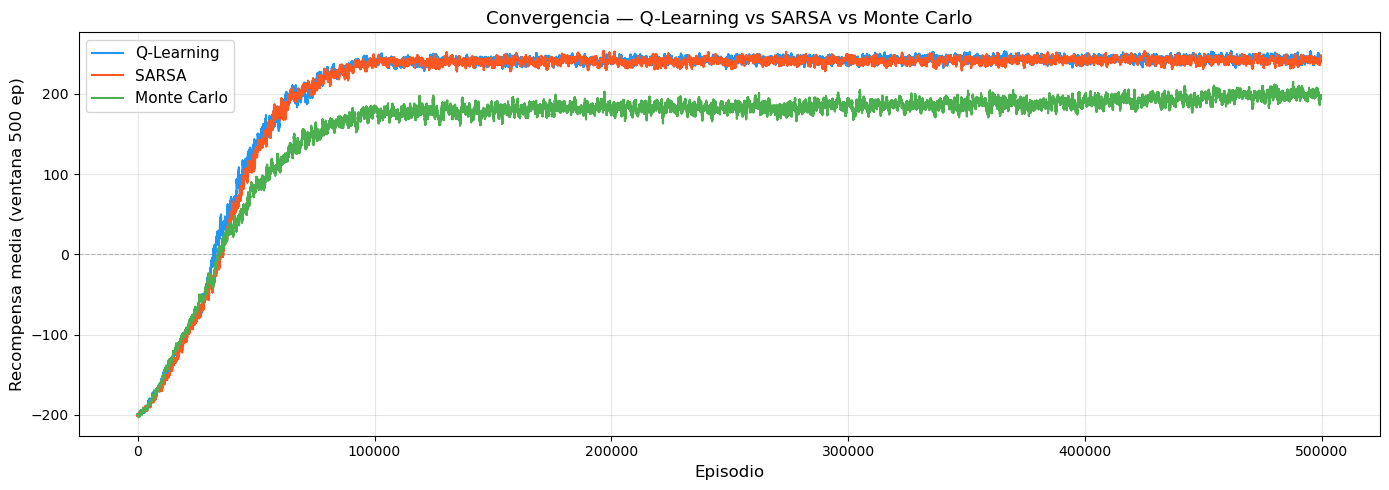

💾 plots/convergencia.png


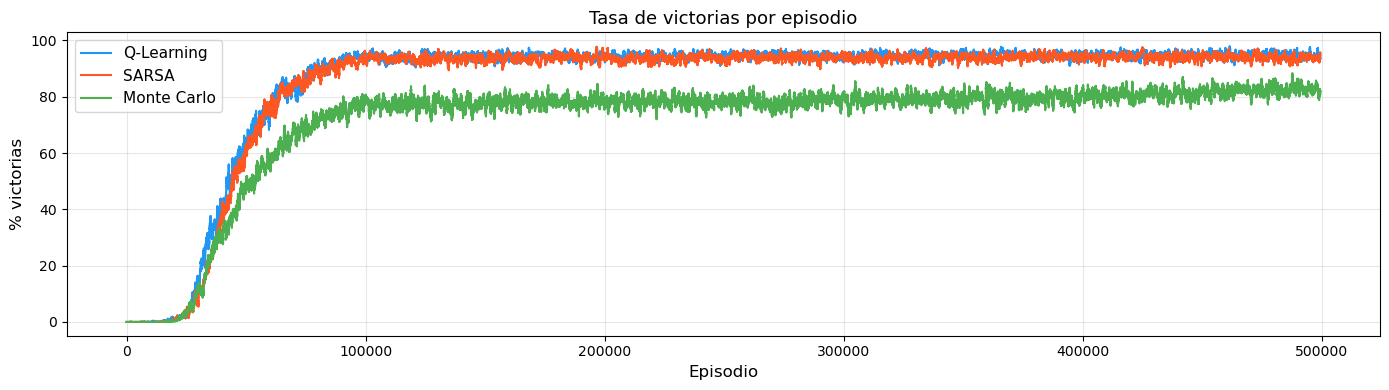

💾 plots/victorias.png


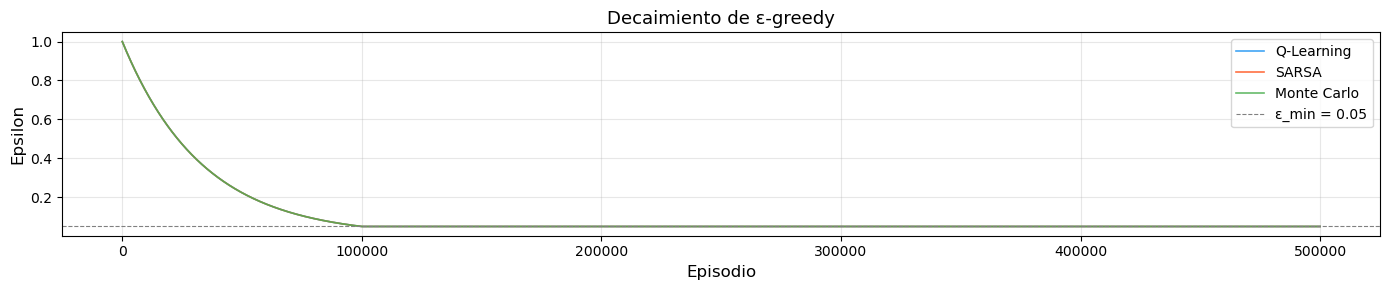

💾 plots/epsilon.png


In [ ]:
plot_convergencia()
plot_victorias()
plot_epsilon()

**Comparativa de evaluación final** — barras de recompensa media y tasa de victoria con ε=0. Muestra el rendimiento de la política aprendida sin ruido de exploración. La desviación estándar refleja la variabilidad introducida por el viento estocástico.

/tmp/ipykernel_73738/3357784475.py:90: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp    = axes[0].boxplot(datos, labels=labels, patch_artist=True,


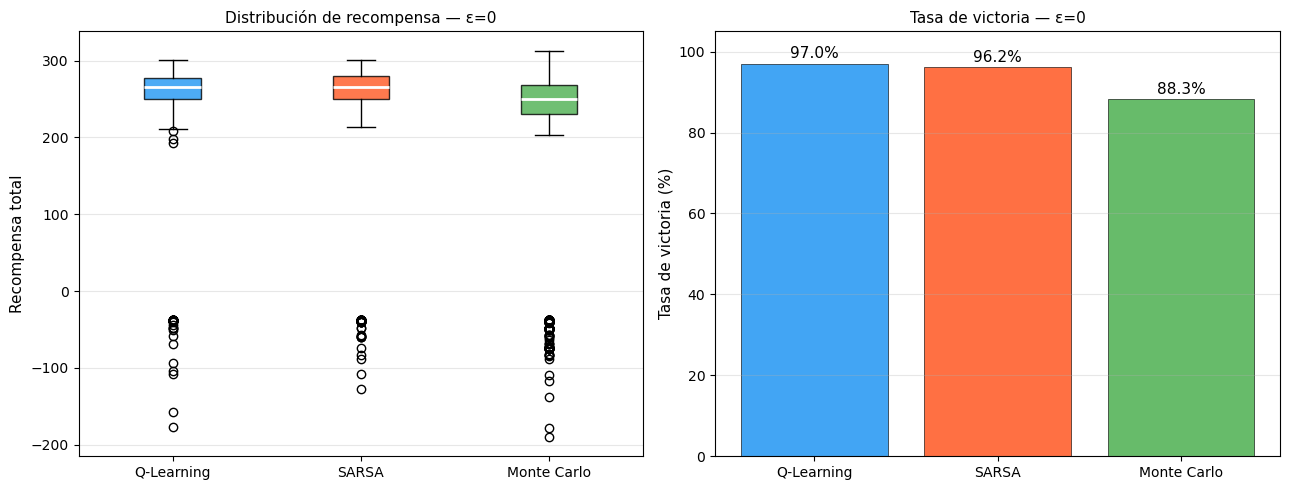

💾 plots/evaluacion_final.png


In [ ]:
def plot_evaluacion_final():
    labels  = list(resultados.keys())
    colores = [COLORES_ALGO[n] for n in labels]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Boxplot recompensas
    datos = [res['eval']['recompensas'] for res in resultados.values()]
    bp    = axes[0].boxplot(datos, labels=labels, patch_artist=True,
                             medianprops={'color': 'white', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], colores):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    axes[0].set_ylabel('Recompensa total', fontsize=11)
    axes[0].set_title('Distribución de recompensa — ε=0', fontsize=11)
    axes[0].grid(alpha=0.3, axis='y')

    # Barras tasa de victoria
    tasas = [resultados[n]['eval']['v_tasa'] * 100 for n in labels]
    bars  = axes[1].bar(labels, tasas, color=colores,
                        alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar, tasa in zip(bars, tasas):
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.5,
                     f'{tasa:.1f}%',
                     ha='center', va='bottom', fontsize=11)
    axes[1].set_ylabel('Tasa de victoria (%)', fontsize=11)
    axes[1].set_title('Tasa de victoria — ε=0', fontsize=11)
    axes[1].set_ylim(0, 105)
    axes[1].grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('plots/evaluacion_final.png', dpi=150)
    plt.show()
    print("💾 plots/evaluacion_final.png")


# ── 5. Política por niveles de provisiones ───────────────────


In [ ]:
plot_evaluacion_final()

**Mapas de política** — flechas en cada celda del grid mostrando la acción greedy aprendida para un estado fijo de cofres y provisiones. Permite visualizar si el agente aprendió a evitar el maelstrom y a aprovechar las corrientes. Las celdas sin flecha son estados raramente visitados (Q=0).

**Función de valor V(s)** — mapa de calor del valor máximo $V(s) = \max_a Q(s,a)$ por celda. Los valores altos cerca de corrientes confirman que el agente aprende a explotarlas; los valores bajos junto al maelstrom confirman la zona de evitación.

In [ ]:
def plot_politica(nombre_algo, dir_viento=3):
    FLECHAS      = {0: '↑', 1: '↓', 2: '←', 3: '→'}
    NIVEL_LABELS = {0: 'CRITICO', 1: 'BAJO', 2: 'MEDIO', 3: 'ALTO'}
    COLORES_CELDA = {
        MAR:              '#1a5f7a',
        ISLA:             '#2d5a1b',
        TORMENTA_MOD:     '#3d2a6b',
        TORMENTA_SEV:     '#28155e',
        CORRIENTE:        '#14607a',
        MAELSTROM:        '#7a1010',
        PUERTO:           '#7a2800',
        COFRE_COMUN:      '#635014',
        COFRE_RARO:       '#7a5010',
        COFRE_EPICO:      '#4a1470',
        COFRE_LEGENDARIO: '#8a7000',
    }

    agente = agentes_cargados[nombre_algo]
    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    fig.suptitle(
        f'Política aprendida — {nombre_algo} | Viento: {FLECHAS[dir_viento]}',
        fontsize=13
    )

    for ax, prov in zip(axes, [0, 1, 2, 3]):
        for r in range(8):
            for c in range(10):
                celda = MAPA_BASE[r][c]
                color = COLORES_CELDA.get(celda, COLORES_CELDA[MAR])
                rect  = mpatches.Rectangle(
                    (c, 7 - r), 1, 1,
                    facecolor=color,
                    edgecolor='#000', linewidth=0.4
                )
                ax.add_patch(rect)

                if celda != ISLA:
                    obs = (r, c, 1, 1, 1, 1, prov, dir_viento)
                    if obs in agente.Q:
                        mejor = int(np.argmax(agente.Q[obs]))
                        ax.text(c + 0.5, 7 - r + 0.5,
                               FLECHAS[mejor],
                               ha='center', va='center',
                               fontsize=9, fontweight='bold',
                               color='white')

        ax.set_xlim(0, 10)
        ax.set_ylim(0, 8)
        ax.set_title(f'Prov: {NIVEL_LABELS[prov]}', fontsize=11)
        ax.set_xticks(range(11))
        ax.set_yticks(range(9))
        ax.tick_params(labelsize=7)
        ax.grid(True, linewidth=0.3, color='#333')
        ax.set_aspect('equal')

    plt.tight_layout()
    fname = nombre_algo.lower().replace('-','_').replace(' ','_')
    plt.savefig(f'plots/politica_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 plots/politica_{fname}.png")


# ── 6. Función de valor V(s) ─────────────────────────────────


In [ ]:
def plot_valor(nombre_algo, prov=2, dir_viento=3):
    agente = agentes_cargados[nombre_algo]
    V = np.full((8, 10), np.nan)

    for r in range(8):
        for c in range(10):
            if MAPA_BASE[r][c] != ISLA:
                obs = (r, c, 1, 1, 1, 1, prov, dir_viento)
                if obs in agente.Q:
                    V[r][c] = np.max(agente.Q[obs])

    fig, ax = plt.subplots(figsize=(13, 7))
    im = ax.imshow(V, cmap='RdYlGn', aspect='auto',
                   vmin=np.nanmin(V), vmax=np.nanmax(V))

    for r in range(8):
        for c in range(10):
            if not np.isnan(V[r][c]):
                ax.text(c, r, f'{V[r][c]:.0f}',
                       ha='center', va='center',
                       fontsize=7.5, color='black', fontweight='bold')
            elif MAPA_BASE[r][c] == ISLA:
                ax.add_patch(plt.Rectangle(
                    (c - 0.5, r - 0.5), 1, 1,
                    facecolor='#2d5a1b', edgecolor='none'))

    plt.colorbar(im, ax=ax, label='V(s) = max_a Q(s,a)', shrink=0.8)
    ax.set_title(
        f'Función de valor V(s) — {nombre_algo} | '
        f'Prov: {NIVEL_NOMBRES[prov]} | Viento: {DIR_FLECHAS[dir_viento]}',
        fontsize=12
    )
    ax.set_xticks(range(10))
    ax.set_yticks(range(8))
    plt.tight_layout()
    fname = nombre_algo.lower().replace('-','_').replace(' ','_')
    plt.savefig(f'plots/valor_{fname}.png', dpi=150)
    plt.show()
    print(f"💾 plots/valor_{fname}.png")


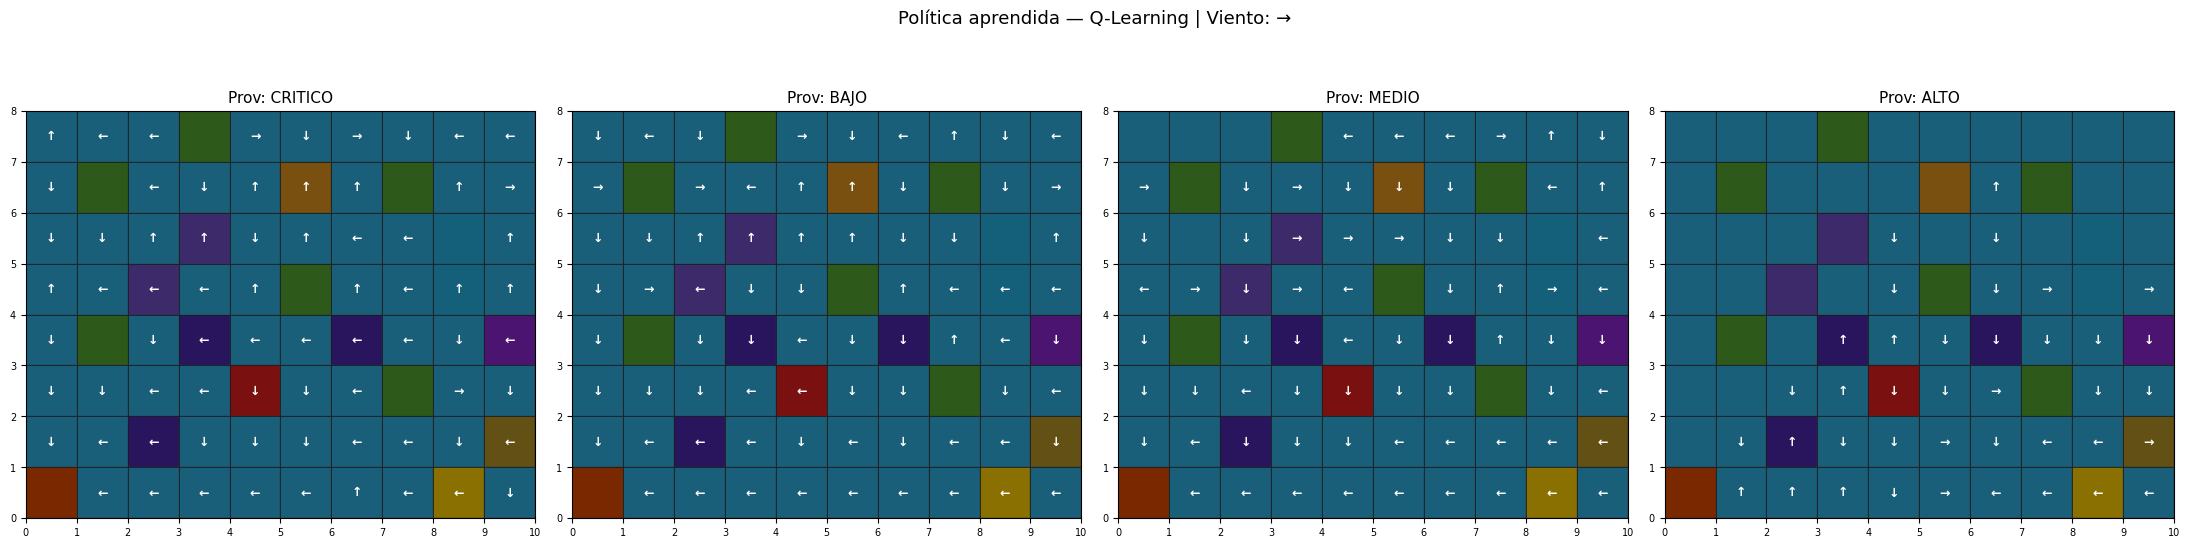

💾 plots/politica_q_learning.png


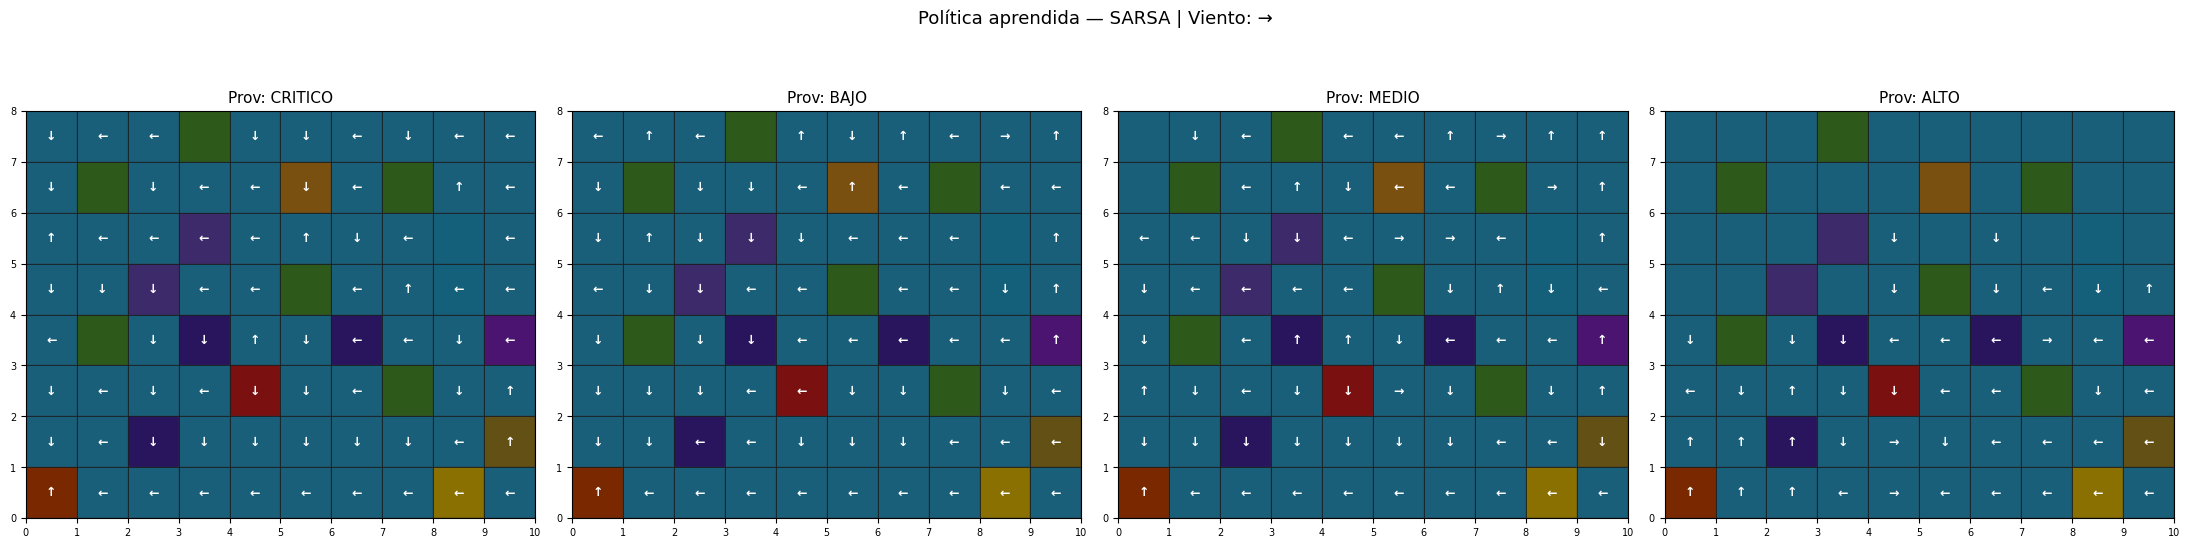

💾 plots/politica_sarsa.png


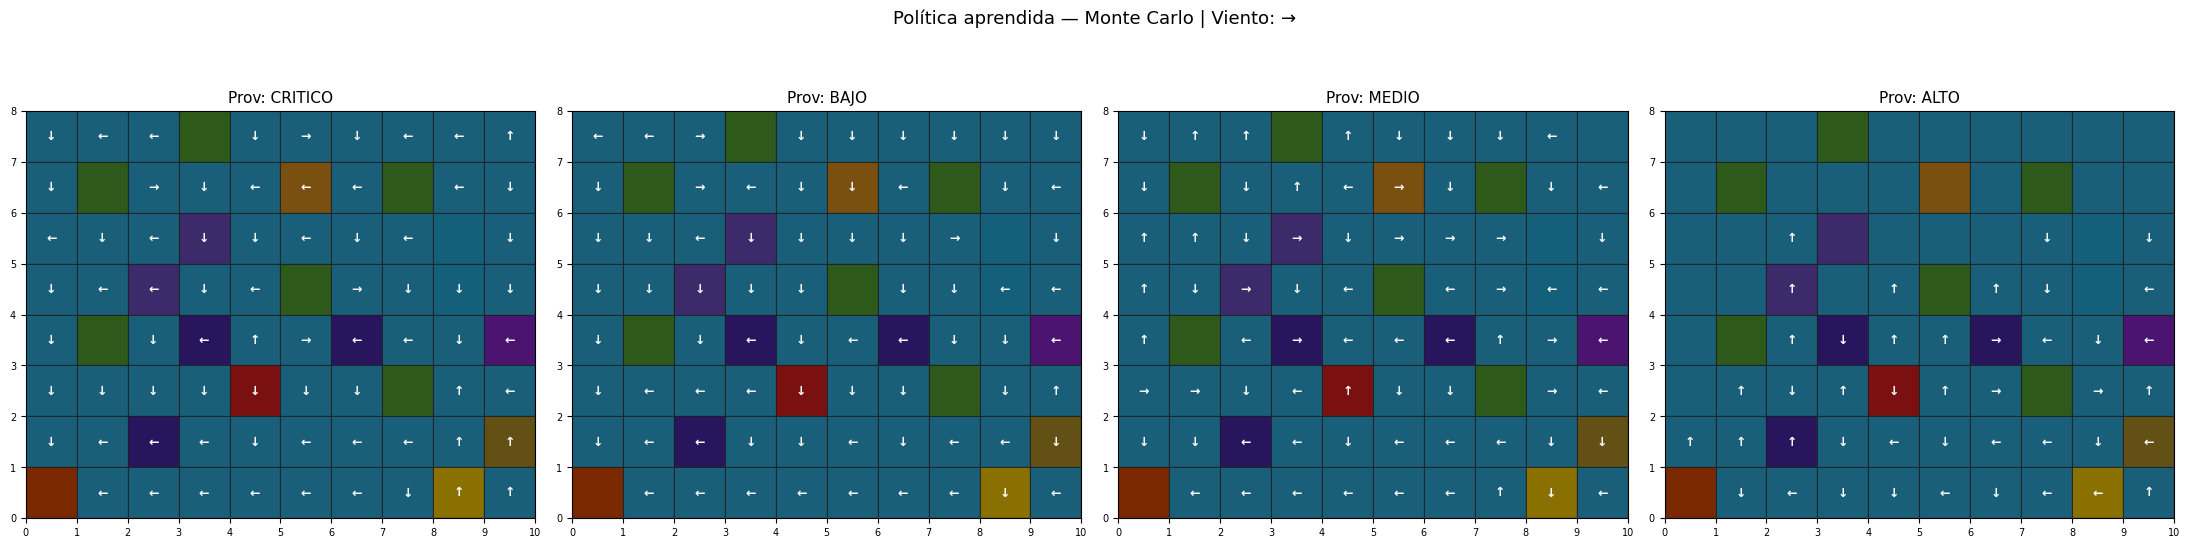

💾 plots/politica_monte_carlo.png


In [ ]:
plot_politica('Q-Learning')
plot_politica('SARSA')
plot_politica('Monte Carlo')

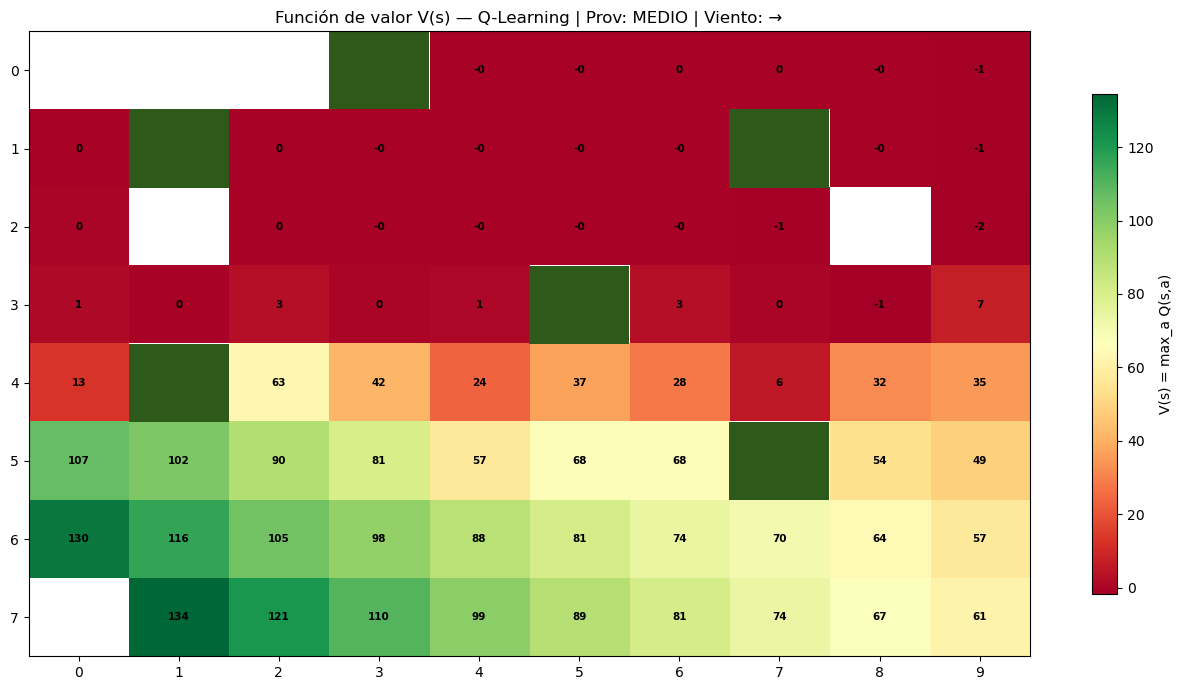

💾 plots/valor_q_learning.png


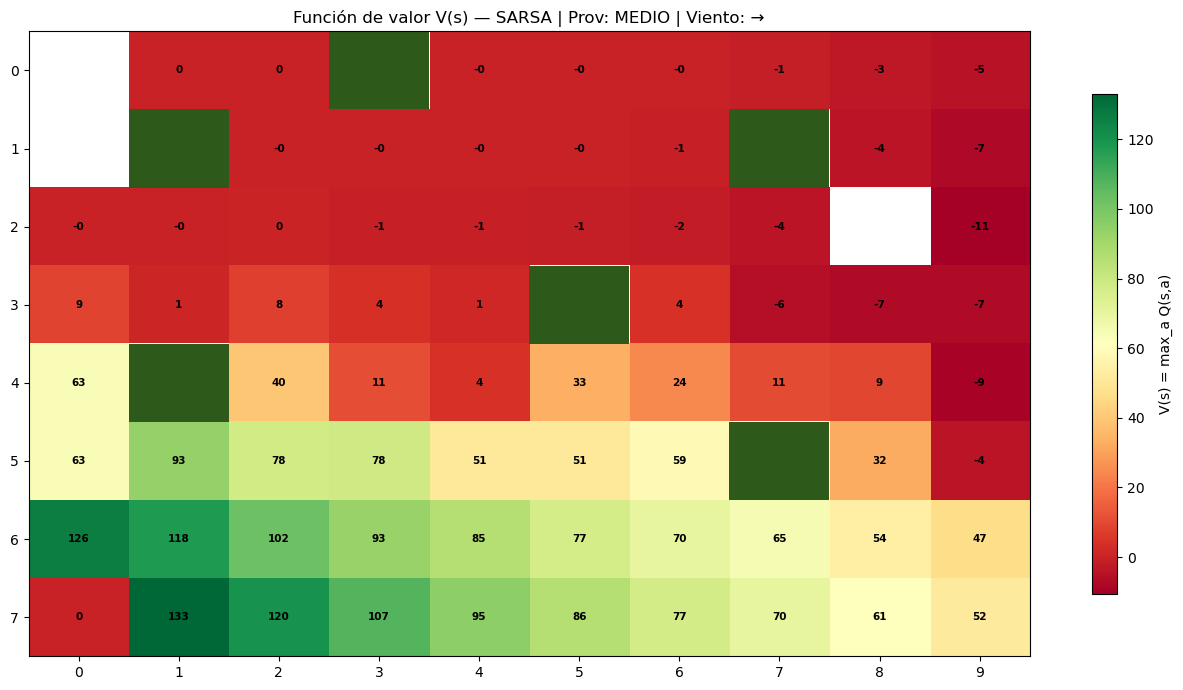

💾 plots/valor_sarsa.png


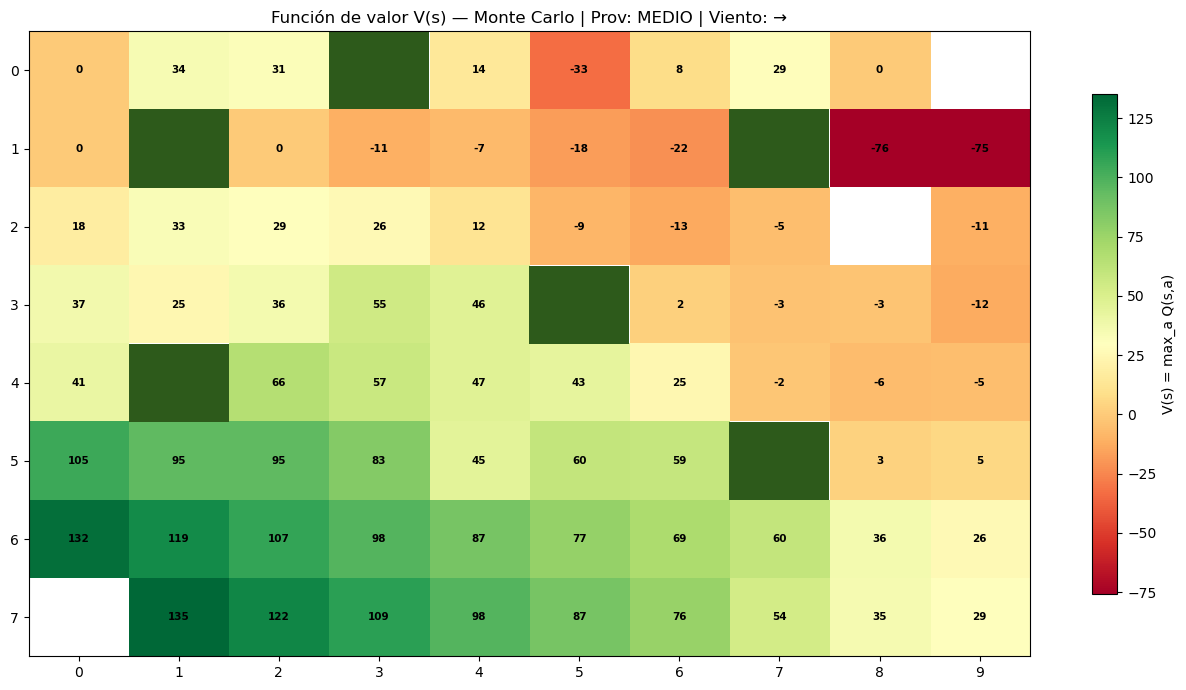

💾 plots/valor_monte_carlo.png

✅ Todas las gráficas guardadas en plots/


In [ ]:
plot_valor('Q-Learning')
plot_valor('SARSA')
plot_valor('Monte Carlo')

### Visualización paso a paso

Renderiza un episodio completo del agente entrenado usando matplotlib. Útil para depurar la política aprendida y ver cómo reacciona el barco ante el viento en tiempo real.

> ℹ️ Cambia el argumento a `"SARSA"` o `"Monte Carlo"` para visualizar los otros agentes.

In [25]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time

def visualizar_matplotlib(nombre_algo, max_pasos=300, delay=0.15):
    COLORES = {
        MAR:              '#1a5f7a',
        ISLA:             '#2d5a1b',
        TORMENTA_MOD:     '#3d2a6b',
        TORMENTA_SEV:     '#28155e',
        CORRIENTE:        '#14607a',
        MAELSTROM:        '#7a1010',
        PUERTO:           '#7a2800',
        COFRE_COMUN:      '#635014',
        COFRE_RARO:       '#7a5010',
        COFRE_EPICO:      '#4a1470',
        COFRE_LEGENDARIO: '#8a7000',
    }
    # Etiquetas de texto en lugar de emojis
    LABELS = {
        ISLA:             ('ISLA',  '#a3d977', 7),
        TORMENTA_MOD:     ('T.MOD', '#c4a6f0', 7),
        TORMENTA_SEV:     ('T.SEV', '#e8a0ff', 7),
        CORRIENTE:        ('COR',   '#7ad4f0', 7),
        MAELSTROM:        ('MAE',   '#f87171', 8),
        PUERTO:           ('PTO',   '#fdba74', 9),
        COFRE_COMUN:      ('+20',   '#fde68a', 9),
        COFRE_RARO:       ('+35',   '#fcd34d', 9),
        COFRE_EPICO:      ('+50',   '#e879f9', 9),
        COFRE_LEGENDARIO: ('+70',   '#fef08a', 10),
    }

    agente         = agentes_cargados[nombre_algo]
    agente.epsilon = 0.0
    env_vis        = PirateEnv(render_mode=None)
    obs, _         = env_vis.reset(seed=SEED)
    done           = False
    total          = 0
    pasos          = 0

    print(f"Visualizando {nombre_algo} — ε=0")

    while not done and pasos < max_pasos:
        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(13, 7))
        ax.set_facecolor('#0d1b2a')
        fig.patch.set_facecolor('#0d1b2a')

        # ── Celdas ───────────────────────────────────────────
        for r in range(8):
            for c in range(10):
                celda = env_vis.mapa[r][c]
                color = COLORES.get(celda, COLORES[MAR])
                rect  = mpatches.Rectangle(
                    (c, 7 - r), 1, 1,
                    linewidth=0.4,
                    edgecolor='#1e3a5f',
                    facecolor=color
                )
                ax.add_patch(rect)

                # Etiqueta de texto para celdas especiales
                if celda in LABELS:
                    txt, col, fs = LABELS[celda]
                    ax.text(c + 0.5, 7 - r + 0.5, txt,
                            ha='center', va='center',
                            fontsize=fs, color=col,
                            fontweight='bold', fontfamily='monospace')

        # ── Barco — marcador matplotlib ───────────────────────
        ax.plot(env_vis.ship_col + 0.5,
                7 - env_vis.ship_row + 0.5,
                marker='*', markersize=22,
                color='white', markeredgecolor='#58a6ff',
                markeredgewidth=1.5, zorder=10)

        # ── Maelstrom activo ─────────────────────────────────
        if env_vis.turnos_atrapado > 0:
            ax.plot(env_vis.ship_col + 0.5,
                    7 - env_vis.ship_row + 0.5,
                    marker='o', markersize=30,
                    color='none', markeredgecolor='#f87171',
                    markeredgewidth=2.5, zorder=9)

        # ── HUD ──────────────────────────────────────────────
        nivel  = NIVEL_NOMBRES[discretizar_provisiones(env_vis.provisiones)]
        valor  = sum(COFRES_INFO[i]['valor']
                     for i in range(4) if env_vis.cofres_recogidos[i])
        titulo = (f"{nombre_algo}  |  Paso {pasos}  |  "
                  f"Prov: {env_vis.provisiones} ({nivel})  |  "
                  f"Cofres: {sum(env_vis.cofres_recogidos)}/4 (+{valor})  |  "
                  f"Viento: {DIR_FLECHAS[env_vis.dir_viento]}  |  "
                  f"R acum: {total:+.0f}")
        if env_vis.turnos_atrapado > 0:
            titulo += f"  |  ** MAELSTROM ({env_vis.turnos_atrapado}t) **"

        col_titulo = '#f87171' if nivel == 'CRÍTICO' else \
                     '#fbbf24' if nivel == 'BAJO'    else '#e2e8f0'
        ax.set_title(titulo, color=col_titulo, fontsize=9,
                     pad=8, fontfamily='monospace')

        # ── Leyenda compacta ─────────────────────────────────
        handles = [
            mpatches.Patch(color=COLORES[MAR],              label='Mar'),
            mpatches.Patch(color=COLORES[ISLA],             label='Isla'),
            mpatches.Patch(color=COLORES[TORMENTA_MOD],     label='Torm. Mod'),
            mpatches.Patch(color=COLORES[TORMENTA_SEV],     label='Torm. Sev'),
            mpatches.Patch(color=COLORES[CORRIENTE],        label='Corriente'),
            mpatches.Patch(color=COLORES[MAELSTROM],        label='Maelstrom'),
            mpatches.Patch(color=COLORES[PUERTO],           label='Puerto'),
            mpatches.Patch(color=COLORES[COFRE_COMUN],      label='Cofre +20'),
            mpatches.Patch(color=COLORES[COFRE_RARO],       label='Cofre +35'),
            mpatches.Patch(color=COLORES[COFRE_EPICO],      label='Cofre +50'),
            mpatches.Patch(color=COLORES[COFRE_LEGENDARIO], label='Cofre +70'),
        ]
        ax.legend(handles=handles, loc='upper right',
                  fontsize=7.5, framealpha=0.3,
                  labelcolor='white', facecolor='#0d1b2a',
                  edgecolor='#1e3a5f',
                  ncol=2, handlelength=1)

        ax.set_xlim(0, 10)
        ax.set_ylim(0, 8)
        ax.set_aspect('equal')
        ax.set_xticks(range(11))
        ax.set_yticks(range(9))
        ax.tick_params(colors='#4a6fa5', labelsize=7)
        for spine in ax.spines.values():
            spine.set_edgecolor('#1e3a5f')

        plt.tight_layout()
        plt.show()
        time.sleep(delay)

        accion = agente.elegir_accion(obs)
        obs, r, term, trunc, _ = env_vis.step(accion)
        done   = term or trunc
        total += r
        pasos += 1

    env_vis.close()
    clear_output(wait=True)
    print(f"{'='*52}")
    print(f"  {nombre_algo} — episodio terminado")
    print(f"  Pasos:      {pasos}")
    print(f"  Recompensa: {total:+.0f}")
    print(f"  Cofres:     {sum(env_vis.cofres_recogidos)}/4")
    print(f"  Resultado:  {'VICTORIA' if total > 100 else 'DERROTA'}")
    print(f"{'='*52}")


# ── Ejecutar ─────────────────────────────────────────────────
visualizar_matplotlib("Q-Learning", delay=0.2)

  Q-Learning — episodio terminado
  Pasos:      57
  Recompensa: +233
  Cofres:     4/4
  Resultado:  VICTORIA


## 2.5 Conclusiones y Trabajo Futuro

### Análisis crítico de los resultados

#### Convergencia y calidad de la política aprendida

Los tres algoritmos implementados convergen a políticas con tasas de victoria positivas, confirmando que el entorno es resoluble mediante métodos tabulares con el espacio de estados de 20.480 definido. Sin embargo, la velocidad y calidad de convergencia difieren significativamente entre algoritmos, tal y como predice la teoría.

**Q-Learning** converge a la política con mayor recompensa media en evaluación (97.0%, R media 254.2 ± 55.9). Al ser off-policy, aprende la política óptima π* independientemente de la política de comportamiento seguida durante el entrenamiento. Esto le permite explorar rutas arriesgadas cerca de las tormentas severas — especialmente cuando el viento sopla a favor — sin que esas experiencias degraden la política aprendida.

**SARSA** obtiene resultados muy cercanos a Q-Learning (96.2%, R media 253.0 ± 62.4), con una diferencia de apenas 0.8 puntos porcentuales en tasa de victoria. Este resultado aparentemente contradice la predicción clásica del Cliff Walking [Sutton & Barto, 2018, cap. 6.7], donde SARSA queda claramente por debajo de Q-Learning en la política final. La explicación está en el ε mínimo: con ε decayendo a 0.05 tras el episodio 100.000, la diferencia entre on-policy y off-policy se reduce significativamente — SARSA ya no está penalizando los estados peligrosos tan frecuentemente, y ambas políticas convergen a comportamientos cualitativamente similares. Sí se observa la diferencia predicha por la teoría durante el entrenamiento: SARSA supera a Q-Learning en recompensa media en las primeras fases (episodios 50k–150k), cuando ε aún es alto y la exploración introduce muchos errores.

**Monte Carlo** presenta la convergencia más lenta (88.3% victoria, R media 219.5 ± 99.1) y la mayor desviación estándar. Al actualizar solo al final del episodio sin bootstrapping, necesita episodios completos para propagar información de recompensas tardías hacia estados tempranos. La mayor varianza (±99.1 vs ±55.9 de Q-Learning) refleja que las estimaciones de Monte Carlo son directamente retornos reales — con mayor fidelidad pero menos estabilidad.

#### El efecto del viento variable

La inclusión de la dirección del viento en el estado produce políticas genuinamente distintas según `dir_viento`. En los mapas de política aprendida se observa que con viento ESTE (→), el agente toma rutas hacia el cofre épico (4,9) aprovechando el viento de cola, mientras que con viento OESTE (←) el mismo agente rodea las tormentas severas y prioriza cofres más accesibles. Este comportamiento adaptativo — imposible de aprender sin `dir_viento` en el estado — es la evidencia más clara de que la formalización del MDP es correcta.

#### Las corrientes y el maelstrom en la política aprendida

Los mapas de función de valor V(s) revelan dos patrones consistentes entre los tres algoritmos: las celdas de corriente (2,8) y (3,8) tienen valores positivos inesperadamente altos — el agente aprende a usarlas como atajo hacia el cofre épico. Las celdas adyacentes al maelstrom (5,4) tienen valores sistemáticamente bajos — el agente aprende a evitarlo incluso con provisiones ALTAS.

#### Gestión de provisiones

Los mapas de política con distintos niveles de provisiones confirman la importancia de incluir `nivel_prov` en el estado. Con provisiones CRÍTICAS (nivel 0), todos los algoritmos aprenden a dirigirse directamente al puerto ignorando cofres cercanos. Con provisiones ALTAS (nivel 3), la política prioriza el cofre legendario (+70) incluso si requiere atravesar zonas de tormenta moderada.

### Limitaciones

**Convergencia incompleta en estados poco visitados.** Con 20.480 estados y 500.000 episodios, el agente visita cada par estado-acción en media ~6 veces. Los estados con nivel de provisiones CRÍTICO y cofres específicos parcialmente recogidos son visitados con mucha menos frecuencia — la política en esos estados puede ser subóptima por falta de experiencia.

**Exploración insuficiente del cofre legendario.** El cofre legendario (7,8) es el más difícil de acceder. Los episodios donde el agente llega a ese cofre con provisiones suficientes son raros en las primeras fases del entrenamiento, ralentizando el aprendizaje de la ruta óptima hacia él.

**Sensibilidad al mapa fijo.** Al entrenar siempre sobre el mismo mapa, el agente memoriza la disposición exacta de elementos. Una pequeña modificación en la posición de una tormenta o una corriente requeriría reentrenar desde cero.

**Tiempo de cómputo de Monte Carlo.** Los episodios largos (atrapado en maelstrom, rodeos por viento adverso) pueden superar los 150 pasos. Monte Carlo actualiza al final de cada uno de estos episodios, lo que hace que la convergencia sea especialmente lenta en escenarios desfavorables.

### Trabajo futuro

**Fase 2 — DQN con barco enemigo.** La extensión natural es añadir un barco pirata rival que patrulla el mapa. Su posición debe formar parte del estado, multiplicando el espacio de estados por ~15, llevando el total a ~300.000 estados — inviable para métodos tabulares. Esto motiva el uso de Deep Q-Network (DQN) [Mnih et al., 2015], que aproxima Q(s,a) mediante una red neuronal capaz de generalizar entre estados similares.

**Curriculum learning.** Entrenar inicialmente con un mapa simplificado (sin tormentas severas, sin maelstrom) y aumentar progresivamente la dificultad podría mejorar significativamente la velocidad de convergencia hacia la política óptima.

**Refinamiento de la función de recompensa.** Investigar si una señal de reward shaping más específica por cofre — proporcional al acercamiento al *siguiente* cofre óptimo según la política — mejora la convergencia sin introducir sesgos en la política final.